In [1]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
from numpy import loadtxt
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, gaussian_kde
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']  # or 'Arial' if Helvetica isn't available


rc = {'axes.labelsize': 15, 
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 12}
plt.rcParams.update(**rc)




helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()




# Figure 1: #

In [ ]:

from pylab import *
import os
from matplotlib.font_manager import FontProperties


helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')


plt.rcParams['font.family'] = helvetica.get_name()
plt.rcParams['font.size'] = 15

# Simulation parameters
N = 1024

os.makedirs('images', exist_ok=True)

# Loop through time frames
for t in range(500, 1000, 4):
    omega_path = os.path.join('..', 'Droplet_data', 'lam_120', 'data', 'omega.' + str(t).zfill(8))
    phi_path = os.path.join('..', 'Droplet_data', 'lam_120', 'data', 'phi.' + str(t).zfill(8))

    # read binary arrays
    amp = fromfile(omega_path, dtype=float64, count=N*N)
    amp1 = amp.reshape((N, N))

    ampp = fromfile(phi_path, dtype=float64, count=N*N)
    amp2 = ampp.reshape((N, N))

    # create figure & axis, show image and add colorbar
    fig, ax = plt.subplots(figsize=(3, 3))
    im = ax.imshow(amp1, extent=[0, 2*pi, 0, 2*pi], origin='lower', aspect='equal', cmap='viridis')
    ax.contour(amp2, extent=[0, 2*pi, 0, 2*pi], origin='lower', cmap='Reds', linewidths=0.7)

    ax.set_xlim(0, 2*pi)
    ax.set_ylim(0, 2*pi)
    ax.set_xlabel('$x$', fontproperties=helvetica)
    ax.set_ylabel('$y$', fontproperties=helvetica)
    ax.set_xticks([])
    ax.set_yticks([])

    # force Helvetica on tick labels (if any)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(helvetica)

    # add a colorbar for the imshow (use small pad so it doesn't push figure)
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.set_label('$\\omega$', fontproperties=helvetica,rotation=90)
    for tlabel in cbar.ax.get_yticklabels():
        tlabel.set_fontproperties(helvetica)

    plt.savefig(os.path.join('images', 't' + str(t).zfill(8) + '.png'), dpi=300, bbox_inches='tight')
    plt.close(fig)


FileNotFoundError: [Errno 2] No such file or directory: '../Droplet_data/lam_120/data/omega.00000500'

(150, 8000)


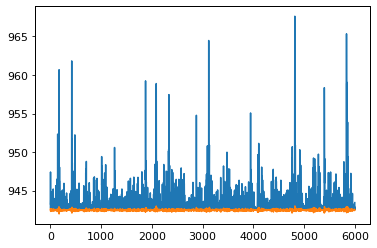

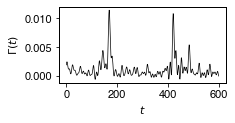

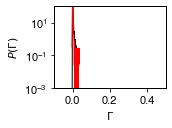

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde

# Load Helvetica font from file
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

# Set Matplotlib global font to Helvetica
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# Update font and axes styles
rc = {'axes.labelsize': 15, 
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 12}
plt.rcParams.update(rc)

def fourier_lowest_modes(signal, num_modes=None, freq_threshold=None):
    num_time_points = len(signal)

    # Compute FFT
    fft_values = np.fft.fft(signal)
    freqs = np.fft.fftfreq(num_time_points)

    # Choose frequency modes
    if num_modes is not None:
        sorted_indices = np.argsort(np.abs(freqs))
        keep_indices = sorted_indices[:num_modes]
    elif freq_threshold is not None:
        keep_indices = np.where(np.abs(freqs) <= freq_threshold)[0]
    else:
        raise ValueError("Either num_modes or freq_threshold must be specified")

    # Truncate FFT
    truncated_fft = np.zeros_like(fft_values, dtype=complex)
    truncated_fft[keep_indices] = fft_values[keep_indices]

    # Reconstruct signal
    reconstructed_signal = np.fft.ifft(truncated_fft).real

    return np.array(reconstructed_signal)

def calculate_perimeter(radius, angles):
    radius = np.array(radius)
    angles = np.array(angles)
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    perimeter = np.sum(ds)
    return perimeter

def calc_deformation(Q_sim, Q_real):
    perimeter_data = []
    perimeter_predict = []
    perimeter0_data = []
    perimeter0_predict = []
    thetas = np.linspace(0, 2*np.pi, 150)
    
    for i in range(2000, 8000): ### inital droplet fluctuations are irregular, wait a bit to settle to a steady state
        sim_plot = Q_sim[:, i] 
        real_plot = Q_real[:, i]
        perimeter_data.append(calculate_perimeter(real_plot, thetas))
        perimeter_predict.append(calculate_perimeter(sim_plot, thetas))
        
        h_real = np.abs(np.trapz(real_plot, thetas))
        h_sim = np.abs(np.trapz(sim_plot, thetas))
        perimeter0_data.append(h_real)
        perimeter0_predict.append(h_sim)
        
    plt.plot(perimeter_data)
    plt.plot(perimeter0_data)
    
    gam_original = (np.array(perimeter_data)/np.array(perimeter0_data)) - 1
    gam_predict = (np.array(perimeter_predict)/np.array(perimeter0_predict)) - 1

    err_1 = np.mean(gam_original) - np.mean(gam_predict)

    gam_predict = fourier_lowest_modes(gam_predict, num_modes=1200) ## option for frequency truncation to remove noise but keep it large here
    gam_original = fourier_lowest_modes(gam_original, num_modes=1200)
    
    # Plot time series
    fig, ax = plt.subplots(figsize=(3, 1.4))
    t = np.linspace(0, len(gam_original), len(gam_original))
    ax.plot(t[:600], gam_original[:600], color="black", label="Original", linewidth=0.7) ## keep 600 to zoom in and see fluctuations clearly
    #ax.plot(t[:600], gam_predict[:600], color="r", label="Predicted", linewidth=0.7, alpha=1)
    ax.set_xlabel("$t$", fontproperties=helvetica)
    ax.set_ylabel(r"$\Gamma(t)$", fontproperties=helvetica)
    
    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)
    
    plt.savefig("mode_hist/Deformation_model_SINDY_data.png", bbox_inches='tight', dpi=500)
    
    # KDE plots with Helvetica fonts and NORMALIZED PDFs
    fig, ax = plt.subplots(figsize=(2, 1.5))
    x_data_plot = gam_original
    x_sim_plot = gam_predict
    
    kde_data = gaussian_kde(x_data_plot)
    kde_sim = gaussian_kde(x_sim_plot)
    
    x_min = min(min(x_data_plot), min(x_sim_plot))
    x_max = max(max(x_data_plot), max(x_sim_plot))
    x_vals = np.linspace(x_min, x_max, 1000)
    
    # Evaluate KDEs
    pdf_data = kde_data(x_vals)
    pdf_sim = kde_sim(x_vals)
    
    # Normalize PDFs to ensure they integrate to 1
    pdf_data_normalized = pdf_data / np.trapz(pdf_data, x_vals)
    pdf_sim_normalized = pdf_sim / np.trapz(pdf_sim, x_vals)
    
    # Plot normalized PDFs
    ax.plot(x_vals, pdf_data_normalized, color='black', label='ground truth', linewidth=1)
    ax.plot(x_vals, pdf_sim_normalized, color='r', alpha=1, label='predicted model', linewidth=1)
    
    ax.set_xlabel('$\Gamma$', fontproperties=helvetica)
    ax.set_ylabel('$P(\Gamma)$', fontproperties=helvetica)
    ax.set_yscale("log")
    ax.set_xlim(-0.1, 0.5)
    ax.set_ylim(0.001, 100)
    
    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)
    
    plt.savefig('mode_hist/GAM_dist_couple_SINDY.png', bbox_inches='tight', dpi=500)
    plt.show()
    
    # Return normalized PDFs
    return gam_original, x_vals, pdf_data_normalized, pdf_sim_normalized, gam_original, gam_predict

# Load data
file = 200
file_sim = f'lang_reg_data6/{file}_Q_sim.txt.npy' 
file_real = f'lang_reg_data6/{file}_Q_real.txt.npy'
Q_sim = np.load(file_sim) + 150
Q_real = np.load(file_real) + 150

print(Q_sim.shape)
thetas = np.linspace(0, 2 * np.pi, 200)

x_gam, x_200, real_200, sim_200, y_data, y_sim = calc_deformation(Q_sim, Q_real)
gam_original1 = y_data

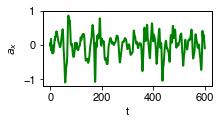

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# Load Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

def read_data(file):
    t = []
    ax = []
    with open(f'time_series_forcasing/{file}.dat', 'r') as file:
        for line in file:
            # Split the line into two parts
            parts = line.split()
            # Append the parts to the respective lists
            t.append(float(parts[0]))
            ax.append(float(parts[1]))
    return t, ax

list2 = [70, 80, 100, 120, 150, 170]
scale_list = []

n = 4
filename = f'accx_{list2[n]}'
        
t, a = read_data(filename)


# Create plot with Helvetica font and green color
plt.figure(figsize=(3.2, 1.8))
plt.plot(a[:600], color='green', linewidth=2) ## zoom in to see fluctuations clearly
plt.xlabel('t', fontproperties=helvetica)
plt.ylabel('$a_x$', fontproperties=helvetica)
#plt.title(f'Acceleration data (L={list2[n]})', fontproperties=helvetica)

# Set tick labels to Helvetica
ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.yticks([-1, 0, 1])
plt.savefig('mode_hist/acceleration_plot.png', bbox_inches='tight', dpi=400)
plt.show()

# Figure 4: #

/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/1965771314.py:129: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


Saved: km_trajectory.png, km_occupancy.png, km_drift.png, km_diffusion.png, km_tau_convergence.png


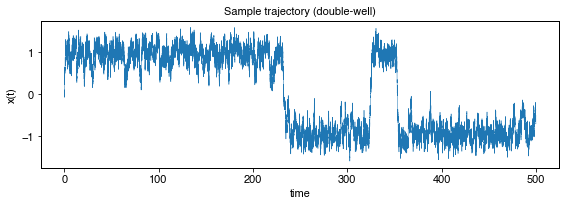

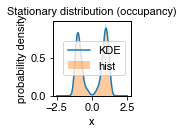

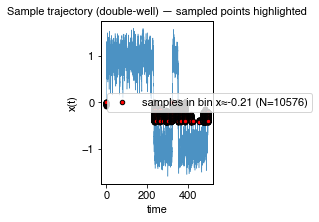

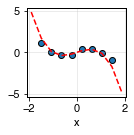

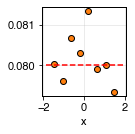

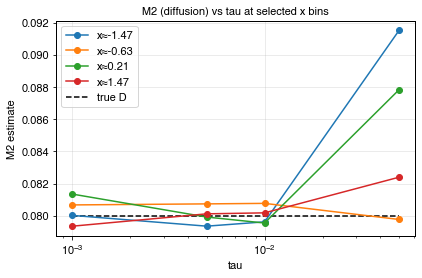

In [9]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.font_manager import FontProperties

# register local Helvetica and set global rcParams robustly
helvetica_path = '/home/samuel/Documents/fonts_hel/Helvetica.ttf'
FontProperties(fname=helvetica_path)
helvetica = FontProperties(fname=helvetica_path)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial'],
    'font.size': 11,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

np.random.seed(1)

# --- SDE params (overdamped Langevin) ---
D = 0.08                 # diffusion coefficient (M2 should approach D)
dt = 1e-3                # timestep
T = 500.0                # total time
N = int(T / dt)
x0 = 0.0

# double-well potential U(x) = 1/4 x^4 - 1/2 x^2  => U'(x) = x^3 - x
def Uprime(x):
    return x**3 - x

# Euler-Maruyama: dx = A(x) dt + sqrt(2 D) dW, A(x) = -U'(x)
sqrt2D = np.sqrt(2 * D)
x = np.empty(N+1)
x[0] = x0
for i in range(N):
    xi = x[i]
    drift = -Uprime(xi)
    x[i+1] = xi + drift * dt + sqrt2D * np.sqrt(dt) * np.random.randn()

t = np.linspace(0, T, N+1)

# --- Figures: time series and occupancy ---
plt.figure(figsize=(8,3))
plt.plot(t, x, lw=0.5)
plt.xlabel('time', fontproperties=helvetica)
plt.ylabel('x(t)', fontproperties=helvetica)
plt.title('Sample trajectory (double-well)', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
plt.tight_layout()
plt.savefig('km_trajectory.png', dpi=150, bbox_inches='tight')

plt.figure(figsize=(2,2))
# occupancy KDE + histogram
xs = np.linspace(-2.5, 2.5, 400)
kde = gaussian_kde(x)
plt.plot(xs, kde(xs), label='KDE')
plt.hist(x, bins=60, density=True, alpha=0.4, label='hist')
plt.xlabel('x', fontproperties=helvetica)
plt.ylabel('probability density', fontproperties=helvetica)
plt.title('Stationary distribution (occupancy)', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
legend = plt.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)
plt.tight_layout()
plt.savefig('km_occupancy.png', dpi=150, bbox_inches='tight')

# --- Kramers-Moyal estimates ---
# choose lags (in multiples of dt) to test tau-dependence
lag_steps = [1, 5, 10, 50]  # corresponds to tau = lag_steps * dt
taus = np.array(lag_steps) * dt

# binning in x for conditional averages
bin_edges = np.linspace(-2.1, 2.1, 11)
bin_centers = 0.5*(bin_edges[:-1]+bin_edges[1:])

def estimate_KM(x, lag):
    # returns arrays aligned with x[:-lag] vs bin centers
    dx = x[lag:] - x[:-lag]
    x_ref = x[:-lag]
    M1 = np.full(len(bin_centers), np.nan)
    M2 = np.full(len(bin_centers), np.nan)
    counts = np.zeros(len(bin_centers), int)
    for j in range(len(bin_centers)):
        lo, hi = bin_edges[j], bin_edges[j+1]
        mask = (x_ref >= lo) & (x_ref < hi)
        cnt = mask.sum()
        counts[j] = cnt
        if cnt >= 30:  # only estimate where we have enough samples
            M1[j] = np.mean(dx[mask]) / (lag*dt)
            M2[j] = np.mean(dx[mask]**2) / (2 * lag*dt)
    return M1, M2, counts

# compute for the smallest lag and for multiple taus for convergence check
M1_1, M2_1, counts = estimate_KM(x, lag_steps[0])

# mark sampled points used in the conditional average on the trajectory
lag = lag_steps[0]                     # same lag used for the KM estimate plotted
# choose a bin to highlight: here pick bin nearest x=0 (change target_x if desired)
target_x = 0.0
idx = np.argmin(np.abs(bin_centers - target_x))

# build mask of reference points that fell into that bin
dx = x[lag:] - x[:-lag]
x_ref = x[:-lag]
mask = (x_ref >= bin_edges[idx]) & (x_ref < bin_edges[idx+1])
t_ref = t[:-lag][mask]
x_sample = x_ref[mask]

# replot trajectory and overlay sampled points
plt.figure(figsize=(2,3))
plt.plot(t, x, lw=0.5, alpha=0.8)
plt.scatter(t_ref, x_sample, color='red', s=20, edgecolor='k', zorder=5,
            label=f'samples in bin x≈{bin_centers[idx]:.2f} (N={mask.sum()})')
plt.xlabel('time', fontproperties=helvetica)
plt.ylabel('x(t)', fontproperties=helvetica)
plt.title('Sample trajectory (double-well) — sampled points highlighted', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
legend = plt.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)
plt.tight_layout()
plt.savefig('km_trajectory_marked.png', dpi=150, bbox_inches='tight')

# plot drift estimate vs theory
theory_drift = -(Uprime(bin_centers))  # A(x) = -U'(x)

plt.figure(figsize=(2.,2.))
plt.scatter(bin_centers, M1_1, c='C0', edgecolor='k', label='estimated M1 (tau=dt)')
plt.plot(bin_centers, theory_drift, 'r--', lw=1.5, label='theoretical drift A(x)')
plt.xlabel('x', fontproperties=helvetica)
#plt.ylabel('M1(x)', fontproperties=helvetica)
#plt.title('Kramers–Moyal first coefficient (drift)', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
#legend = plt.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('km_drift.png', dpi=150, bbox_inches='tight')

# plot diffusion estimate vs known D
plt.figure(figsize=(2.,2.))
plt.scatter(bin_centers, M2_1, c='C1', edgecolor='k', label=f'estimated M2 (tau=dt)')
plt.hlines(D, bin_centers[0], bin_centers[-1], colors='r', linestyles='--', label=f'true D={D:.3f}')
plt.xlabel('x', fontproperties=helvetica)
#plt.ylabel('M2(x)', fontproperties=helvetica)
#plt.title('Kramers–Moyal second coefficient (diffusion)', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
#legend = plt.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('km_diffusion.png', dpi=150, bbox_inches='tight')

# tau convergence at a few x positions (select bins with good counts)
good_idx = np.where(counts >= 200)[0]
# pick up to 4 representative bins
sel_idx = good_idx[np.linspace(0, len(good_idx)-1, min(4, len(good_idx))).astype(int)] if len(good_idx)>0 else np.array([len(bin_centers)//2])
plt.figure(figsize=(6,4))
for idx in sel_idx:
    M2_vals = []
    M1_vals = []
    for lag in lag_steps:
        M1_l, M2_l, _ = estimate_KM(x, lag)
        M2_vals.append(M2_l[idx])
        M1_vals.append(M1_l[idx])
    label = f'x≈{bin_centers[idx]:.2f}'
    plt.plot(taus, M2_vals, 'o-', label=label)
plt.hlines(D, taus[0], taus[-1], colors='k', linestyles='--', label='true D')
plt.xscale('log')
plt.xlabel('tau', fontproperties=helvetica)
plt.ylabel('M2 estimate', fontproperties=helvetica)
plt.title('M2 (diffusion) vs tau at selected x bins', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
legend = plt.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('km_tau_convergence.png', dpi=150, bbox_inches='tight')

print("Saved: km_trajectory.png, km_occupancy.png, km_drift.png, km_diffusion.png, km_tau_convergence.png")


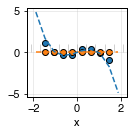

In [10]:
plt.figure(figsize=(2.,2.))
plt.scatter(bin_centers, M1_1, c='C0', edgecolor='k', label='estimated M1 (tau=dt)')
plt.plot(bin_centers, theory_drift, 'C0--', lw=1.5, label='theoretical drift A(x)')
plt.xlabel('x', fontproperties=helvetica)
#plt.ylabel('M1(x)', fontproperties=helvetica)
#plt.title('Kramers–Moyal first coefficient (drift)', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
#legend = plt.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)


plt.scatter(bin_centers, M2_1, c='C1', edgecolor='k', label=f'estimated M2 (tau=dt)')
plt.hlines(D, bin_centers[0], bin_centers[-1], colors='C1', linestyles='--', label=f'true D={D:.3f}')
plt.vlines(bin_edges, ymin=0, ymax=1, colors='gray', lw=0.6, alpha=0.6)
plt.xlabel('x', fontproperties=helvetica)
#plt.ylabel('M2(x)', fontproperties=helvetica)
#plt.title('Kramers–Moyal second coefficient (diffusion)', fontproperties=helvetica)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(helvetica)
#legend = plt.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('km_diffusion.png', dpi=150, bbox_inches='tight')

# Figure 5: #

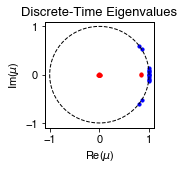

In [11]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np

helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

discrete_eigs = np.loadtxt('mode_hist/Qtd_dmd_real_eigen.txt', dtype=complex)
discrete_eigs_simple = np.loadtxt('mode_hist/Qtd_dmd_simple_real_eigen.txt', dtype=complex)
theta = np.linspace(-np.pi, np.pi, 500)

plt.figure(figsize=(2.5, 2.5))
plt.scatter(discrete_eigs_simple.real, discrete_eigs_simple.imag, color='red', s=10, label='DMD')
plt.scatter(discrete_eigs.real, discrete_eigs.imag, color='blue', s=10, label='Hankel DMD')
plt.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1)  # Unit circle

# Set axis labels and title with Helvetica
plt.title("Discrete-Time Eigenvalues", fontsize=13, fontproperties=helvetica)
plt.xlabel("Re(" + r'$\mu$' + ")", fontproperties=helvetica)
plt.ylabel("Im(" + r'$\mu$' + ")", fontproperties=helvetica)

# Set tick labels to Helvetica
ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig('mode_hist/dmd_eigenvalue_plot.png', dpi=300, bbox_inches='tight')

0.02728452716666667
0.02928254025


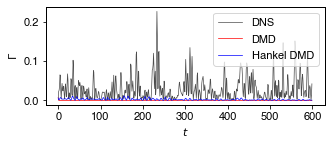

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np

# Set Helvetica font globally for matplotlib
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

def read_floats_from_file(filename):
    floats = []
    with open(filename, 'r') as file:
        for line in file:
            floats.append(float(line.strip()))
    return floats

gam_list = ['200']
plt.figure(figsize=(5, 1.8))

for gam_number in gam_list:
    # Data loading
    x_data_plot = np.loadtxt(f'mode_hist/gama_dmd_td_real.txt')
    x_dmd_td_plot = np.loadtxt(f'mode_hist/gama_dmd_td_sim.txt')
    x_dmd_plot = np.loadtxt(f'mode_hist/gama_dmd_sim.txt')
    time = np.arange(0, len(x_data_plot), 1)
    x_dmd_td_plot[0]=x_data_plot[0]
    x_dmd_plot[0]=x_data_plot[0]

    # Plot the data with labels and improved styles
    plt.plot(time[:600], np.array(x_data_plot[:600]), color='black', linewidth=0.7, label='DNS', alpha=0.7)
    plt.plot(time[:600], np.array(x_dmd_plot[:600]), color='red', linewidth=0.7, linestyle='-', label='DMD')
    plt.plot(time[:600], np.array(x_dmd_td_plot[:600]), color='blue', linewidth=0.7, linestyle='-', label='Hankel DMD')

    # Set axis labels with Helvetica
    plt.xlabel(r'$t$', fontproperties=helvetica)
    plt.ylabel(r'$\Gamma$', fontproperties=helvetica)
    #plt.ylim(-0.0001,0.006)
    # Set tick labels to Helvetica
    ax = plt.gca()
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

    # Set legend font to Helvetica
    legend = plt.legend(loc='upper right')
    for text in legend.get_texts():
        text.set_fontproperties(helvetica)

plt.savefig('mode_hist/gamma_DMD.png', bbox_inches='tight', dpi=500)

error_hankel = np.mean(np.abs(np.array(x_data_plot[:600]) - np.array(x_dmd_td_plot[:600])))
error_DMD = np.mean(np.abs(np.array(x_data_plot[:600]) - np.array(x_dmd_plot[:600])))
print(error_hankel)
print(error_DMD)

correlation_matrix_H = np.corrcoef(np.array(x_data_plot[:600]), np.array(x_dmd_td_plot[:600]))
correlation_matrix_DMD = np.corrcoef(np.array(x_data_plot[:600]), np.array(x_dmd_plot[:600]))

correlation_H = correlation_matrix_H[0, 1]
correlation_DMD = correlation_matrix_DMD[0, 1]

# Figure 6: #

/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/332048628.py:36: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("PiYG").copy()
  cmap.set_bad(color='white')


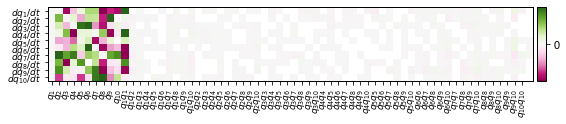

(10, 66)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap

# Load Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Load coefficient matrix for ST=200 only
ST = 200
coeffs = np.loadtxt(f'data/coeffs_sindy/sindy_coeff_matrix_{ST}.txt', dtype=float)

# Create labels for y-axis (modes)
labels_y = [f'$dq_{{{i}}}/dt$' for i in range(1, 11)]

# Create labels for x-axis (terms)
num_x = coeffs.shape[1]
labels_x = []
for i in range(min(num_x, 10)):
    labels_x.append(f'$q_{{{i+1}}}$')

count = 10
for i in range(1, 11):
    for j in range(i, 11):
        if count >= num_x:
            break
        labels_x.append(f'$q_{{{i}}}q_{{{j}}}$')
        count += 1
    if count >= num_x:
        break

# Create custom colormap with white at zero
cmap = plt.cm.PiYG
cmap.set_bad(color='white')

# Create masked array where zeros are masked
coeffs_masked = np.ma.masked_where(coeffs == 0, coeffs)

# Create single subplot
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(coeffs_masked, cmap=cmap, vmin=-500, vmax=500)

# Set tick labels for both axes
ax.set_yticks(np.arange(len(labels_y)))
ax.set_yticklabels(labels_y, fontsize=9, fontproperties=helvetica)
ax.set_xticks(np.arange(len(labels_x)))
ax.set_xticklabels(labels_x, rotation=90, fontsize=9, fontproperties=helvetica)

# Add colorbar to the right of the plot
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='2%', pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_ticks([-700, 0, 700])
cbar.set_ticklabels(['-1000', '0', '1000'])

# Set Helvetica font for colorbar tick labels
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig(f'mode_hist/coeffs_{ST}', dpi=500)
plt.show()
print(coeffs.shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde

# Load Helvetica font from file
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

# Set Matplotlib global font to Helvetica
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# Update font and axes styles
rc = {'axes.labelsize': 15, 
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 12}
plt.rcParams.update(rc)
def fourier_lowest_modes_matrix(signal_matrix, num_modes=None, freq_threshold=None):
    
    num_time_points, num_signals = signal_matrix.shape
    truncated_matrix = np.zeros_like(signal_matrix)
    truncated_ffts = np.zeros((num_time_points, num_signals), dtype=complex)
    
    for i in range(num_signals):
        signal = signal_matrix[:, i]
        
        # Compute FFT
        fft_values = np.fft.fft(signal)
        
        # Get the frequencies corresponding to each FFT bin
        freqs = np.fft.fftfreq(num_time_points)
        
        # Find the indices of the lowest frequency modes
        if num_modes is not None:
            # Get indices sorted by absolute frequency (DC first, then increasing frequencies)
            sorted_indices = np.argsort(np.abs(freqs))
            keep_indices = sorted_indices[:num_modes]
        elif freq_threshold is not None:
            # Keep all frequencies below the threshold (absolute value)
            keep_indices = np.where(np.abs(freqs) <= freq_threshold)[0]
        else:
            raise ValueError("Either num_modes or freq_threshold must be specified")
        
        # Create truncated FFT by zeroing out non-selected modes
        truncated_fft = np.zeros_like(fft_values, dtype=complex)
        truncated_fft[keep_indices] = fft_values[keep_indices]
        truncated_ffts[:, i] = truncated_fft
        
        # Reconstruct signal from truncated FFT
        reconstructed_signal = np.fft.ifft(truncated_fft).real
        truncated_matrix[:, i] = reconstructed_signal
    
    return truncated_matrix, truncated_ffts
def calculate_perimeter(radius, angles):
    radius = np.array(radius)
    angles = np.array(angles)
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    perimeter = np.sum(ds)
    return perimeter

def calc_deformation(Q_sim, Q_real):
    perimeter_data = []
    perimeter_predict = []
    perimeter0_data = []
    perimeter0_predict = []
    thetas = np.linspace(0, 2*np.pi,150)
    offset= Q_sim[:,0] - Q_real[:,0]
    
    
    for i in range(0, 1200):
        sim_plot = Q_sim[:,i]
        real_plot = Q_real[:,i]
        perimeter_data.append(calculate_perimeter(real_plot, thetas))
        perimeter_predict.append(calculate_perimeter(sim_plot, thetas))
        
        h_real = np.abs(np.trapz(real_plot, thetas))
        h_sim = np.abs(np.trapz(sim_plot, thetas))
        perimeter0_data.append(h_real)
        perimeter0_predict.append(h_sim)
        
    #plt.plot(perimeter_data)
    #plt.plot(perimeter0_data)
    
    gam_original = (np.array(perimeter_data)/np.array(perimeter0_data))-1
    gam_predict = (np.array(perimeter_predict)/np.array(perimeter0_predict))-1

    
    gam_original=gam_original
    gam_predict = gam_predict
    
    
    # Plot time series
    #fig, ax = plt.subplots(figsize=(2.7,1.2))
    #t = np.linspace(0,len(gam_original),len(gam_original))
    #ax.plot(t[:1200], gam_original[:1200], color="black", label="Original", linewidth=0.7)
    #ax.plot(t[:1200], gam_predict[:1200], color="r", label="Predicted", linewidth=1., alpha=1)
    #ax.set_xlabel("$t$", fontproperties=helvetica)
    #ax.set_ylabel(r"$\Gamma(t)$", fontproperties=helvetica)
    #ax.legend(prop=helvetica)
    
    # Set tick labels to Helvetica
    #for label in ax.get_xticklabels():
    #    label.set_fontproperties(helvetica)
    #for label in ax.get_yticklabels():
    #    label.set_fontproperties(helvetica)
    
    #plt.savefig("mode_hist/Deformation_model_SINDY.png", bbox_inches='tight', dpi=500)
    
    # KDE plots with Helvetica fonts
    fig, ax = plt.subplots(figsize=(1.7, 1.3))
    x_data_plot = gam_original
    x_sim_plot = gam_predict
    
    kde_data = gaussian_kde(x_data_plot)
    kde_sim = gaussian_kde(x_sim_plot)
    
    x_min = min(min(x_data_plot), min(x_sim_plot))
    x_max = max(max(x_data_plot), max(x_sim_plot))
    x_vals = np.linspace(x_min, x_max, 100)
    
    ax.plot(x_vals, kde_data(x_vals), color='black', label='ground truth', linewidth=1)
    ax.plot(x_vals, kde_sim(x_vals), color='r', alpha=1, label='predicted model', linewidth=1)
    
    ax.set_xlabel('$\Gamma$', fontproperties=helvetica)
    ax.set_ylabel('$P(\Gamma)$', fontproperties=helvetica)
    #ax.legend(prop=helvetica)
    ax.set_yscale("log")
    #ax.set_xlim(-0.001,0.01)
    ax.set_ylim(0.01,1000)

    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)
    
    plt.savefig('mode_hist/GAM_dist_couple_SINDY.png', bbox_inches='tight', dpi=500)
   
    plt.show()

    ## compare power spectral density
    #fig, ax = plt.subplots(figsize=(2.7, 2.3))

    # Calculate PSD using matplotlib's psd function (it also plots)
   
    #psd_original, freqs_original = ax.psd(gam_original, NFFT=512, Fs=1, color='black', label='Original', linewidth=1)
    #psd_predict, freqs_predict = ax.psd(gam_predict, NFFT=512, Fs=1, color='r', label='Predicted', linewidth=1)
    
    #ax.set_xlabel('Frequency', fontproperties=helvetica)
    #ax.set_ylabel('Power Spectral Density', fontproperties=helvetica)
    #ax.legend(prop=helvetica)

    # Set tick labels to Helvetica
    #for label in ax.get_xticklabels():
    #    label.set_fontproperties(helvetica)
    #for label in ax.get_yticklabels():
    #    label.set_fontproperties(helvetica)

    #plt.tight_layout()
    
    #plt.show()
    #MSE_power = np.mean((psd_original - psd_predict)**2)
    MSE_power=1
    return gam_original, x_vals, kde_data(x_vals), kde_sim(x_vals), gam_original, gam_predict,MSE_power

### SINDY generalisation

f=10
for n in [50,75,85,100,120,140,160,180,200]:
    
    
    x_sim = 0.7*np.loadtxt(f'data/coeffs_sindy/sindy_sim_{n}{f}.txt', dtype=float).T
    x_sim=x_sim[:10, :]
    x_sim = x_sim 
    kde_sim_list=[]
    kde_data_list=[]
    x_vals_list=[]

    h1=np.loadtxt(f'h_{n}.txt').T
    h_sub=np.array(h1)[:,:8000]
    U,S,Vt=np.linalg.svd(h_sub)
    r=10
    Ur_200=U[:,:r]

    gam_real_ST=[]
    gam_sim_ST=[]
    MSE_list=[]
    MSE_power_list=[]
    for ST in [50,75,85,100,120,140,160,180,200]:
        print('ST', n,ST)
        #h1=np.loadtxt(f'mode_hist/Qtrue_{ST}{f}.txt')
        h1=np.loadtxt(f'h_test/h_{ST}.txt').T

        h_sub=np.array(h1)[:,:8000]
        
        U,S,Vt=np.linalg.svd(h_sub)
        r=10
        Ur=U[:,:r]
        Sr=S[:r]
        Vtr=Vt[:r,:]
        Vtr, _=fourier_lowest_modes_matrix(Vtr.T, num_modes=100)
        Vtr=Vtr.T
        Vtr=Vtr/np.max(np.abs(Vtr), axis=1, keepdims=True)
        ## truncate fourier modes
        
        
        print(Vtr.shape)
        print(x_sim.shape)

        
        h_reconstructed=np.dot(Ur,np.dot(np.diag(Sr),Vtr))+2000
        #h_reconstructed=h_sub+2000
        h_reconstructed_sindy=np.dot(Ur_200,np.dot(np.diag(Sr),x_sim))+2000

        
        h_reconstructed_sindy=h_reconstructed_sindy
        gam_original, x_vals,kde_data,kde_sim, gam_original,gam_predict,MSE_power=calc_deformation(h_reconstructed_sindy,h_reconstructed)
        MSE_power_list.append(MSE_power)
        MSE=np.mean((gam_original - gam_predict)**2)
        MSE_list.append(MSE)
        plt.plot(gam_original,color='black')
        plt.plot(gam_predict,color='red')
        
        kde_sim_list.append(kde_sim)
        kde_data_list.append(kde_data)
        x_vals_list.append(x_vals)
        gam_real_ST.append(gam_original)
        gam_sim_ST.append(gam_predict)
    

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.font_manager import FontProperties
    import matplotlib.cm as cm
    from scipy.stats import entropy, gaussian_kde

    # Set Helvetica font
    helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
    plt.rcParams['font.family'] = helvetica.get_name()

    # Create colormap for different ST values
    ST_values = [50,75, 85,100, 120, 140,160, 180, 200]
    colors = cm.get_cmap('viridis')(np.linspace(0, 1, len(ST_values)))

    plt.figure(figsize=(5.5, 4.5))
    kl_divergence_list = []

    for i, ST in enumerate(ST_values):
        gam_real = gam_real_ST[i]
        gam_sim = gam_sim_ST[i]
        
        # Create KDEs
        kde_data = gaussian_kde(gam_real)
        kde_sim = gaussian_kde(gam_sim)
        
        # Use a common x_vals range covering both distributions
        x_min = min(np.min(gam_real), np.min(gam_sim))
        x_max = max(np.max(gam_real), np.max(gam_sim))
        x_vals = np.linspace(x_min, x_max, 1000)
        
        # Evaluate PDFs
        p = kde_data(x_vals)
        q = kde_sim(x_vals)
        
        # Add small epsilon to avoid log(0)
        epsilon = 1e-10
        p = p + epsilon
        q = q + epsilon
        
        # Normalize to ensure they are proper probability distributions
        p = p / np.trapz(p, x_vals)  # Normalize by integrating
        q = q / np.trapz(q, x_vals)
        
        # Calculate KL divergence: D_KL(P||Q) = sum(p * log(p/q))
        # Using numerical integration for continuous distributions
        kl_divergence = np.trapz(p * np.log(p / q), x_vals)
        kl_divergence_list.append(kl_divergence)
        
        print(f'ST={ST}: KL divergence = {kl_divergence:.6f}')

    # Plot KL vs ST
    plt.figure(figsize=(3.5,3))
    ax = plt.gca()
    plt.plot(ST_values, kl_divergence_list, marker='o', linestyle='-', color='green', linewidth=2)
    plt.xlabel('$\Lambda$', fontproperties=helvetica)
    plt.ylabel('KL Divergence', fontproperties=helvetica)
    plt.xticks(ST_values)
    #plt.grid(True, alpha=0.3)

    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

    plt.tight_layout()
    #plt.savefig(f'mode_hist/KLD/kl_divergence_sindy4_{n}.png', bbox_inches='tight', dpi=500)
    #np.savetxt(f'mode_hist/KLD/kl_divergence_sindy4_{n}.txt', kl_divergence_list, fmt='%.6f')
    #np.savetxt(f'mode_hist/KLD/MSE_sindy4_{n}.txt', MSE_list, fmt='%.6f')
    #np.savetxt(f'mode_hist/KLD/MSE_power_sindy4_{n}.txt', MSE_power_list, fmt='%.6f')
    plt.show()



KeyboardInterrupt: 

# Figure 7: #

Original matrix shape: (9, 9)
Matrix columns: 9


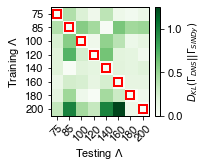


Difference Matrix Statistics:
Max positive difference (worst generalization): 1.255248e+00
Min difference (should be 0 on diagonal): 0.000000e+00


In [ ]:
### generalisation matrix
import numpy as np
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt

kl_200=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_200.txt')
kl_180=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_180.txt')
kl_160=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_160.txt')
kl_140=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_140.txt')
kl_120=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_120.txt')
kl_100=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_100.txt')
kl_85=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_85.txt')
kl_75=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_75.txt')
kl_50=np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_50.txt')

generalisation_matrix=np.array([kl_50,kl_75,kl_85,kl_100,kl_120,kl_140,kl_160,kl_180,kl_200])
print(f"Original matrix shape: {generalisation_matrix.shape}")
print(f"Matrix columns: {len(generalisation_matrix[0])}")

# Extract the relevant part (skip first column as in original)
matrix = generalisation_matrix[1:,1:]

# Calculate difference from diagonal for each row
diagonal_diff_matrix = np.zeros_like(matrix)
diagonal_values_list = []
for i in range(matrix.shape[0]):
    diagonal_value = matrix[i, i]  # Diagonal element in row i
    diagonal_diff_matrix[i, :] =np.abs(matrix[i, :]-diagonal_value) # Small constant to avoid log(0)
    diagonal_values_list.append(diagonal_value)
    #print(f"Row {i}: diagonal value = {diagonal_value:.6e}")
matrix2=diagonal_diff_matrix
# Plot the difference matrix
plt.figure(figsize=(2.2, 2))
im = plt.imshow((diagonal_diff_matrix), cmap='Greens', aspect='auto')]
cbar = plt.colorbar(im)
cbar.set_label('$D_{KL}(\Gamma_{DNS}||\Gamma_{SINDy})$', fontsize=10, fontproperties=helvetica)

# Mark diagonal elements with red squares
for i in range(min(matrix.shape)):
    plt.plot(i, i, 'rs', markersize=8, markerfacecolor='none', 
             markeredgewidth=2, markeredgecolor='red')
ST_vals=[75,85,100,120,140,160,180,200]
plt.xticks(ticks=np.arange(len(ST_vals)), labels=ST_vals, fontproperties=helvetica,rotation=45)
plt.yticks(ticks=np.arange(len(ST_vals)), labels=ST_vals, fontproperties=helvetica)
plt.xlabel('Testing $\Lambda$', fontproperties=helvetica)
plt.ylabel('Training $\Lambda$', fontproperties=helvetica)
#plt.title('Generalization Error Relative to In-Domain', fontproperties=helvetica, fontsize=10)

# Set Helvetica font for colorbar tick labels
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.savefig('mode_hist/generalisation_matrix_diagonal_diff.png', bbox_inches='tight', dpi=500)
plt.show()

# Print statistics
print("\nDifference Matrix Statistics:")
print(f"Max positive difference (worst generalization): {np.max(diagonal_diff_matrix):.6e}")
print(f"Min difference (should be 0 on diagonal): {np.min(diagonal_diff_matrix):.6e}")


In [ ]:
plt.figure(figsize=(2.5,2.2))
ax = plt.gca()
ST_values = ST_vals  # Exclude the first ST value (75)
plt.plot(ST_values,matrix2 [-1,:], marker='o', linestyle='-', color='green', linewidth=2)
plt.xlabel('$\Lambda$', fontproperties=helvetica)
plt.ylabel('$D_{KL}(\Gamma_{DNS}||\Gamma_{SINDy})$\n(Trained on $\Lambda=200$)', fontproperties=helvetica)
plt.xticks([75,120,160,200])  # Add rotation parameter
plt.tight_layout()  # Add this to prevent labels from being cut off
plt.savefig(f'mode_hist/kl_divergence_sindy3_200_diff.png', bbox_inches='tight', dpi=500)
plt.show()

Training Λ=75: Mean off-diagonal KL = 1.815351e-01
Training Λ=85: Mean off-diagonal KL = 4.262613e-01
Training Λ=100: Mean off-diagonal KL = 2.826533e-01
Training Λ=120: Mean off-diagonal KL = 3.088081e-01
Training Λ=140: Mean off-diagonal KL = 1.474027e-01
Training Λ=160: Mean off-diagonal KL = 1.764411e-01
Training Λ=180: Mean off-diagonal KL = 2.180204e-01
Training Λ=200: Mean off-diagonal KL = 6.293533e-01


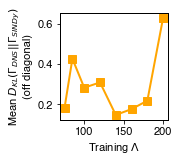


Summary: Average KL Divergence 
Training Λ= 75: 0.181535
Training Λ= 85: 0.426261
Training Λ=100: 0.282653
Training Λ=120: 0.308808
Training Λ=140: 0.147403
Training Λ=160: 0.176441
Training Λ=180: 0.218020
Training Λ=200: 0.629353

Overall mean (all off-diagonal): 0.296309
Standard deviation: 0.151654
Min generalization error: 0.147403 (Training Λ=140)
Max generalization error: 0.629353 (Training Λ=200)


In [19]:
### generalisation matrix - mean excluding diagonal
import numpy as np
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt

helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
mean=np.loadtxt('mode_hist/mean_stats.txt')
var=np.loadtxt('mode_hist/var_stats.txt')
kurtosis=np.loadtxt('mode_hist/kurtosis_stats.txt')
# Extract the relevant part (skip first column as in original)
matrix = matrix2

# Calculate mean of each row excluding diagonal
row_means_excl_diag = []
lambda_values = ST_vals

for i in range(matrix.shape[0]):
    # Create mask for off-diagonal elements
    mask = np.ones(matrix.shape[1], dtype=bool)
    mask[i] = False  # Exclude diagonal element
    
    # Calculate mean of off-diagonal elements
    row_mean = np.mean(matrix[i, mask])
    row_means_excl_diag.append(row_mean)
    
    print(f"Training Λ={lambda_values[i]}: Mean off-diagonal KL = {row_mean:.6e}")

# Plot the row means
plt.figure(figsize=(2.6, 2.3))
ax = plt.gca()

plt.plot(lambda_values, row_means_excl_diag ,'-s', color='orange', linewidth=2, markersize=8)
#plt.plot(lambda_values, mean/np.max(mean), '-o', color='blue', linewidth=2, markersize=8)
#plt.plot(lambda_values, var/np.max(var), '-o', color='green', linewidth=2, markersize=8)
#plt.plot(lambda_values, kurtosis/np.max(kurtosis), '--', color='gray', linewidth=2, markersize=8)
#plt.plot(lambda_values,diagonal_values_list, markersize=8)

plt.xlabel('Training $\Lambda$', fontproperties=helvetica)
plt.ylabel('Mean $D_{KL}(\Gamma_{DNS}||\Gamma_{SINDy})$\n(off diagonal)', fontproperties=helvetica)
#plt.ylabel('Kurtosis\n(training set)', fontproperties=helvetica)
#plt.grid(True, alpha=0.3)

# Set tick labels to Helvetica
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig('mode_hist/row_mean_kl_excl_diagonal.png', bbox_inches='tight', dpi=500)
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("Summary: Average KL Divergence ")
print("="*60)
for i, lam in enumerate(lambda_values):
    print(f"Training Λ={lam:3d}: {row_means_excl_diag[i]:.6f}")

print(f"\nOverall mean (all off-diagonal): {np.mean(row_means_excl_diag):.6f}")
print(f"Standard deviation: {np.std(row_means_excl_diag):.6f}")
print(f"Min generalization error: {np.min(row_means_excl_diag):.6f} (Training Λ={lambda_values[np.argmin(row_means_excl_diag)]})")
print(f"Max generalization error: {np.max(row_means_excl_diag):.6f} (Training Λ={lambda_values[np.argmax(row_means_excl_diag)]})")

# Save results to file
np.savetxt('mode_hist/row_means_excl_diagonal.txt', 
           np.column_stack([lambda_values, row_means_excl_diag]),
           header='Training_Lambda  Mean_KL_excl_diagonal',
           fmt='%d %.6e')


In [20]:
## plot specific distributions
import matplotlib.cm as cm
plt.figure(figsize=(1.8, 1.6))
colors = cm.get_cmap('seismic')(np.linspace(0,0.9,7))
for i, ST in enumerate([50, 75,100, 120,160, 180, 200]):
    if i in [1,2,6]:
        kde_real = kde_data_list[i]
        kde_sim = kde_sim_list[i]
        x_vals = x_vals_list[i]

        # Normalize KDEs by dividing by their maximum values
        kde_real_norm = kde_real / np.max(kde_real)
        kde_sim_norm = kde_sim / np.max(kde_sim)

        plt.scatter(x_vals[::6], kde_real_norm[::6],s=10, color=colors[i],alpha=0.6,label='ground truth' if i==0 else "", linewidth=1)
        plt.plot(x_vals, kde_sim_norm, color=colors[i],alpha=1, label='predicted model' if i==0 else "", linewidth=2)

plt.xlabel('$\Gamma$', fontproperties=helvetica)
plt.ylabel('$P(\Gamma)$', fontproperties=helvetica)
plt.yscale("log")
plt.ylim(0.001, 2)  # Adjusted y-limits for normalized [0, 1] range
ax = plt.gca()
for label in ax.get_xticklabels():
    
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)
#plt.legend(prop=helvetica)
plt.savefig(f'mode_hist/GAM_dist_couple_all.png', bbox_inches='tight', dpi=500)
plt.show()

IndexError: list index out of range

<Figure size 129.6x115.2 with 0 Axes>

In [ ]:
# Plot KL vs ST
kl_divergence_list=kl_100
plt.figure(figsize=(3.5,3))
ax = plt.gca()
plt.plot(ST_values[1:], kl_divergence_list[1:], marker='o', linestyle='-', color='green', linewidth=2)
plt.xlabel('ST', fontproperties=helvetica)
plt.ylabel('KL Divergence', fontproperties=helvetica)
plt.xticks(ST_values[1:])
#plt.grid(True, alpha=0.3)

# Set tick labels to Helvetica
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig(f'mode_hist/kl_divergence_sindy_{n}.png', bbox_inches='tight', dpi=500)
plt.show()

In [ ]:
#S_list=np.load('POD_lam_data.npz',allow_pickle=True)['S_list']
#lam_list=np.load('POD_lam_data.npz',allow_pickle=True)['lam_list']
def find_modes_all(normalized_h_store,ti,tf,n_sim):
    
    dt=2e-4
    
    
    Tf_units=tf*dt
    Ti_units=ti*dt
        
    u=np.array(normalized_h_store).T[:,ti:tf]
    t=np.arange(Ti_units,Tf_units,dt)
    print("lent",len(t))
    
    tot_t_len=len(u[0])
    
    U, S,Vt = np.linalg.svd(u)
    #ip=inner_product(u,thetas)
    #modes,feature_names, S2, Vh=vector_POD(ip,t,4)
    
    
    
    ri = 3
    Ur = U[:, :ri]
    Sr = np.diag(S[:ri])
    modes= Vt[:ri, :]
    
    
    Ur1 = U[:, 0:ri]
    Sr1 = np.diag(S[0:ri])
    modes1= Vt[0:ri, :]
    h_sub_1 = np.dot(Ur1, np.dot(Sr1, modes1))
    
    
   
    
    
    return modes,h_sub_1,S

h_list=[]

ti=0
for files in [50,75,85,120,160,140,180,200]: 
    h_sub=np.loadtxt(f'hs_{files}.txt')
    h_list.append(h_sub)
#h_list.append(h_sub)
n_mode=1
lam_list = ["75","85","100","120", "140","160", "180","200"]
gamma_list=[]
S_list=[]
mean=[]
for lam in range(0,8):
    cop1, h_sub1, S1 = find_modes_all(h_list[lam], ti, 3000, n_mode)
    S_list.append(S1)
    




plt.figure(figsize=(2.2, 1.8))
r=11
modes=np.arange(1,r)

# Create a colormap
cmap = plt.cm.seismic
print(len(lam_list))
colors = cmap(np.linspace(0, 1, len(lam_list)))

for lam in range(8):
    if lam==2:
         plt.plot(modes, S_list[lam][1:r], label=f"$\Lambda={lam_list[lam]}$",color=colors[lam])
    else:
        plt.plot(modes, S_list[lam][1:r], label=f"$\Lambda={lam_list[lam]}$",color=colors[lam])
    #plt.plot([], label=f"$\Lambda={lam_list[lam]}$", color=colors[lam])
    #plt.scatter(modes, S_list[lam][1:r], s=10, color=colors[lam])
    np.savetxt(f'lang_reg_data6/S_{lam_list[lam]}.txt',S_list[lam][1:r])

plt.xlabel('Mode number', fontproperties=helvetica)
plt.ylabel('$\Sigma_{jj}$', fontproperties=helvetica)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)
    
plt.yscale('log')
plt.xticks(modes)

# Create legend with Helvetica font
#legend = plt.legend(prop=helvetica, ncol=4, loc='upper right', fontsize=8)

plt.tight_layout()

plt.savefig("mode_hist/energies.png", bbox_inches='tight', dpi=500)

FileNotFoundError: hs_50.txt not found.

# Figure 8: #

(150, 8000)


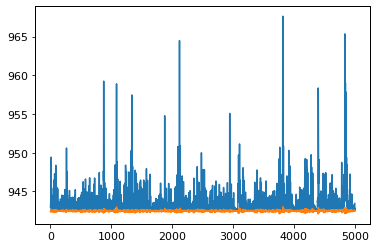

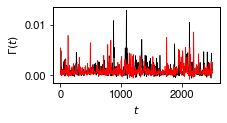

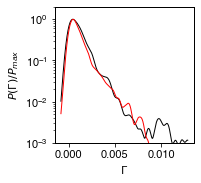

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde

# Load Helvetica font from file
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

# Set Matplotlib global font to Helvetica
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# Update font and axes styles
rc = {'axes.labelsize': 15, 
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 12}
plt.rcParams.update(rc)

def fourier_lowest_modes(signal, num_modes=None, freq_threshold=None):
    num_time_points = len(signal)

    # Compute FFT
    fft_values = np.fft.fft(signal)
    freqs = np.fft.fftfreq(num_time_points)

    # Choose frequency modes
    if num_modes is not None:
        sorted_indices = np.argsort(np.abs(freqs))
        keep_indices = sorted_indices[:num_modes]
    elif freq_threshold is not None:
        keep_indices = np.where(np.abs(freqs) <= freq_threshold)[0]
    else:
        raise ValueError("Either num_modes or freq_threshold must be specified")

    # Truncate FFT
    truncated_fft = np.zeros_like(fft_values, dtype=complex)
    truncated_fft[keep_indices] = fft_values[keep_indices]

    # Reconstruct signal
    reconstructed_signal = np.fft.ifft(truncated_fft).real

    return np.array(reconstructed_signal)

def calculate_perimeter(radius, angles):
    radius = np.array(radius)
    angles = np.array(angles)
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    perimeter = np.sum(ds)
    return perimeter

def calc_deformation(Q_sim, Q_real):
    perimeter_data = []
    perimeter_predict = []
    perimeter0_data = []
    perimeter0_predict = []
    thetas = np.linspace(0, 2*np.pi, 150)
    
    for i in range(1000, 8000):
        sim_plot = Q_sim[:, i] 
        real_plot = Q_real[:, i]
        perimeter_data.append(calculate_perimeter(real_plot, thetas))
        perimeter_predict.append(calculate_perimeter(sim_plot, thetas))
        
        h_real = np.abs(np.trapz(real_plot, thetas))
        h_sim = np.abs(np.trapz(sim_plot, thetas))
        perimeter0_data.append(h_real)
        perimeter0_predict.append(h_sim)
        
    plt.plot(perimeter_data)
    plt.plot(perimeter0_data)
    
    gam_original = (np.array(perimeter_data)/np.array(perimeter0_data)) - 1
    gam_predict = (np.array(perimeter_predict)/np.array(perimeter0_predict)) - 1

    err_1 = np.mean(gam_original) - np.mean(gam_predict)
    
    gam_predict = fourier_lowest_modes(gam_predict, num_modes=1200)
    gam_original = fourier_lowest_modes(gam_original, num_modes=1200)
    
    t_max=2500
    gam_predict[0]=gam_original[0]
    # Plot time series
    fig, ax = plt.subplots(figsize=(3, 1.4))
    t = np.linspace(0, len(gam_original), len(gam_original))
    ax.plot(t[:t_max], gam_original[:t_max], color="black", label="Original", linewidth=0.7)
    ax.plot(t[:t_max], gam_predict[:t_max], color="r", label="Predicted", linewidth=0.7, alpha=1)
    ax.set_xlabel("$t$", fontproperties=helvetica)
    ax.set_ylabel(r"$\Gamma(t)$", fontproperties=helvetica)
    
    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)
    
    plt.savefig("mode_hist/Deformation_model_SINDY.png", bbox_inches='tight', dpi=500)
    
    # KDE plots with Helvetica fonts and NORMALIZED PDFs
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    x_data_plot = gam_original[:t_max]
    x_sim_plot = gam_predict[:t_max]
    
    kde_data = gaussian_kde(x_data_plot)
    kde_sim = gaussian_kde(x_sim_plot)
    
    x_min = min(min(x_data_plot), min(x_sim_plot))
    x_max = max(max(x_data_plot), max(x_sim_plot))
    x_vals = np.linspace(x_min, x_max, 1000)
    
    # Evaluate KDEs
    pdf_data = kde_data(x_vals)
    pdf_sim = kde_sim(x_vals)
    
    # Normalize PDFs so that the max of each KDE is 1
    pdf_data_normalized = pdf_data / np.max(pdf_data)
    pdf_sim_normalized = pdf_sim / np.max(pdf_sim)
    
    # Plot normalized PDFs
    ax.plot(x_vals, pdf_data_normalized, color='black', label='ground truth', linewidth=1)
    ax.plot(x_vals, pdf_sim_normalized, color='r', alpha=1, label='predicted model', linewidth=1)
    
    ax.set_xlabel('$\Gamma$', fontproperties=helvetica)
    ax.set_ylabel('$P(\Gamma) / P_{max}$', fontproperties=helvetica)
    ax.set_yscale("log")
    #ax.set_xlim(-0.05, 0.4)
    ax.set_ylim(0.001, 2)
    
    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)
    
    plt.savefig('mode_hist/GAM_dist_couple_SINDY.png', bbox_inches='tight', dpi=500)
    plt.show()
    
    # Return normalized PDFs
    return gam_original, x_vals, pdf_data_normalized, pdf_sim_normalized, gam_original, gam_predict

# Load data
file = 200
file_sim = f'lang_reg_data6/{file}_Q_sim.txt.npy' 
file_real = f'lang_reg_data6/{file}_Q_real.txt.npy'
Q_sim = np.load(file_sim) + 150
Q_real = np.load(file_real) + 150

print(Q_sim.shape)
thetas = np.linspace(0, 2 * np.pi, 200)

x_gam, x_200, real_200, sim_200, y_data, y_sim = calc_deformation(Q_sim, Q_real)
gam_original1 = y_data

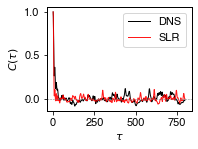

Decorrelation time (DNS):   τ_dec = 36
Decorrelation time (SLR):   τ_dec = 13

KURTOSIS COMPARISON (first 800 points)
Excess kurtosis (DNS):   κ = 4.3222
Excess kurtosis (SLR):   κ = 12.0463
Relative error:          178.71%
──────────────────────────────────────────────────
Pearson kurtosis (DNS):  κ = 7.3222
Pearson kurtosis (SLR):  κ = 15.0463

SUMMARY STATISTICS (first 800 points)
Statistic                     DNS          SLR
──────────────────────────────────────────────────
Mean                     0.000861     0.000926
Std dev                  0.000758     0.001066
Skewness                   1.6779       3.0593
Excess kurtosis            4.3222      12.0463


In [19]:
# --- Normalized Autocorrelation Function C(τ) = ⟨Γ(t+τ)Γ(t)⟩ / ⟨Γ²⟩ ---
# --- and Kurtosis Comparison ---

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy.stats import kurtosis, skew

helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

def normalized_autocorrelation(signal):
    """
    Compute the normalized autocorrelation function:
    C(τ) = ⟨Γ(t+τ) Γ(t)⟩ / ⟨Γ²⟩
    
    Uses FFT-based correlation for efficiency.
    The signal is assumed to have zero mean subtracted.
    """
    signal = np.array(signal, dtype=float)
    signal = signal - np.mean(signal)  # Remove mean to get fluctuations
    N = len(signal)
    
    # FFT-based autocorrelation (Wiener-Khinchin theorem)
    fft_sig = np.fft.fft(signal, n=2*N)  # zero-pad to avoid circular correlation
    power_spectrum = fft_sig * np.conj(fft_sig)
    autocorr_full = np.fft.ifft(power_spectrum).real[:N]
    
    # Normalize by number of overlapping points at each lag
    counts = np.arange(N, 0, -1)
    autocorr = autocorr_full / counts
    
    # Normalize by ⟨Γ²⟩ (variance, i.e. C(0))
    C = autocorr / autocorr[0]
    
    return C

# Compute normalized autocorrelation for data and simulation
C_data = normalized_autocorrelation(y_data)
C_sim = normalized_autocorrelation(y_sim)

# Define lag axis
tau = np.arange(len(C_data))

# Plot autocorrelation
t_max_acf = 800  # number of lags to display (adjust as needed)

fig, ax = plt.subplots(figsize=(3, 2.2))
ax.plot(tau[:t_max_acf], C_data[:t_max_acf], color='black', linewidth=1, label='DNS')
ax.plot(tau[:t_max_acf], C_sim[:t_max_acf], color='r', linewidth=1, label='SLR', alpha=0.9)

ax.set_xlabel(r'$\tau$', fontproperties=helvetica)
ax.set_ylabel(r'$C(\tau)$', fontproperties=helvetica)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Set tick labels to Helvetica
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

legend = ax.legend(prop=helvetica)
for text in legend.get_texts():
    text.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig('mode_hist/autocorrelation_Gamma.png', bbox_inches='tight', dpi=500)
plt.show()

# --- Decorrelation time (first zero crossing) ---
def decorrelation_time(C):
    """Find the lag at which the autocorrelation first crosses zero."""
    zero_crossings = np.where(np.diff(np.sign(C)))[0]
    if len(zero_crossings) > 0:
        return zero_crossings[0]
    return len(C)  # never crosses zero

tau_dec_data = decorrelation_time(C_data)
tau_dec_sim = decorrelation_time(C_sim)
print(f"Decorrelation time (DNS):   τ_dec = {tau_dec_data}")
print(f"Decorrelation time (SLR):   τ_dec = {tau_dec_sim}")

# --- Kurtosis Comparison (computed over plotted region only) ---
y_data_region = y_data[:t_max_acf]
y_sim_region = y_sim[:t_max_acf]

# Fisher kurtosis (excess kurtosis): Gaussian = 0
kurt_data = kurtosis(y_data_region, fisher=True)
kurt_sim = kurtosis(y_sim_region, fisher=True)

# Pearson kurtosis (standard): Gaussian = 3
kurt_data_pearson = kurtosis(y_data_region, fisher=False)
kurt_sim_pearson = kurtosis(y_sim_region, fisher=False)

print(f"\n{'='*50}")
print(f"KURTOSIS COMPARISON (first {t_max_acf} points)")
print(f"{'='*50}")
print(f"Excess kurtosis (DNS):   κ = {kurt_data:.4f}")
print(f"Excess kurtosis (SLR):   κ = {kurt_sim:.4f}")
print(f"Relative error:          {np.abs(kurt_data - kurt_sim) / np.abs(kurt_data) * 100:.2f}%")
print(f"{'─'*50}")
print(f"Pearson kurtosis (DNS):  κ = {kurt_data_pearson:.4f}")
print(f"Pearson kurtosis (SLR):  κ = {kurt_sim_pearson:.4f}")

# Additional statistics for context (over plotted region)
skew_data = skew(y_data_region)
skew_sim = skew(y_sim_region)

print(f"\n{'='*50}")
print(f"SUMMARY STATISTICS (first {t_max_acf} points)")
print(f"{'='*50}")
print(f"{'Statistic':<20} {'DNS':>12} {'SLR':>12}")
print(f"{'─'*50}")
print(f"{'Mean':<20} {np.mean(y_data_region):>12.6f} {np.mean(y_sim_region):>12.6f}")
print(f"{'Std dev':<20} {np.std(y_data_region):>12.6f} {np.std(y_sim_region):>12.6f}")
print(f"{'Skewness':<20} {skew_data:>12.4f} {skew_sim:>12.4f}")
print(f"{'Excess kurtosis':<20} {kurt_data:>12.4f} {kurt_sim:>12.4f}")

In [3]:
cost0 = np.loadtxt('data/lang_cost0.txt')
cost = np.loadtxt('data/lang_cost.txt')
# ascending x positions 1,2,3,...
n = np.arange(1, len(cost0) + 1)
print(n)
plt.figure(figsize=(2.5,2.5))

# reverse the cost arrays so their order is opposite
cost0_rev = cost0[::-1]
cost_rev = (cost)[::-1]

plt.plot(n, cost0_rev, color='#0AF20A', label='$q_0$')
plt.scatter(n, cost0_rev, color='#0AF20A')
plt.plot(n, cost_rev, color='#366636', label='$q_1$')
plt.scatter(n, cost_rev, color='#366636')

# if you instead want the y-axis inverted (large values down), uncomment:
# plt.gca().invert_yaxis()

plt.xlabel('number of terms', fontproperties=helvetica)
plt.ylabel('Cost', fontproperties=helvetica)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)
ticks = [2,4,6,8]
ticks = [t for t in ticks if t <= n.max()]
plt.xticks(ticks)
plt.legend(prop=helvetica)
plt.savefig("mode_hist/cost.png", bbox_inches='tight', dpi=500)
plt.show()

FileNotFoundError: data/lang_cost0.txt not found.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde

# Load Helvetica font from file
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

# Set Matplotlib global font to Helvetica
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# Update font and axes styles
rc = {'axes.labelsize': 15, 
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 12}
plt.rcParams.update(rc)

def calculate_perimeter(radius, angles):
    radius = np.array(radius)
    angles = np.array(angles)
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    perimeter = np.sum(ds)
    return perimeter

def calc_deformation(Q_sim, Q_real):
    perimeter_data = []
    perimeter_predict = []
    perimeter0_data = []
    perimeter0_predict = []
    thetas = np.linspace(0, 2*np.pi,150)
    offset= Q_sim[:,0] - Q_real[:,0]
    
    
    for i in range(0,7000):
        sim_plot = Q_sim[:,i]
        real_plot = Q_real[:,i]
        perimeter_data.append(calculate_perimeter(real_plot, thetas))
        perimeter_predict.append(calculate_perimeter(sim_plot, thetas))
        
        h_real = np.abs(np.trapz(real_plot, thetas))
        h_sim = np.abs(np.trapz(sim_plot, thetas))
        perimeter0_data.append(h_real)
        perimeter0_predict.append(h_sim)
        
    #plt.plot(perimeter_data)
    #plt.plot(perimeter0_data)
    
    gam_original = (np.array(perimeter_data)/np.array(perimeter0_data))-1
    gam_predict = (np.array(perimeter_predict)/np.array(perimeter0_predict))-1

    
    gam_original=gam_original
    gam_predict = gam_predict

    T=10000
    # Plot time series
    #fig, ax = plt.subplots(figsize=(2.7,1.2))
    #t = np.linspace(0,len(gam_original),len(gam_original))
    #ax.plot(t[:T], gam_original[:T], color="black", label="Original", linewidth=0.7)
    #ax.plot(t[:T], gam_predict[:T], color="r", label="Predicted", linewidth=1., alpha=1)
    #ax.set_xlabel("$t$", fontproperties=helvetica)
    #ax.set_ylabel(r"$\Gamma(t)$", fontproperties=helvetica)
    #ax.legend(prop=helvetica)
    
    # Set tick labels to Helvetica
    #for label in ax.get_xticklabels():
    #    label.set_fontproperties(helvetica)
    #for label in ax.get_yticklabels():
    #    label.set_fontproperties(helvetica)
    
    plt.savefig("mode_hist/Deformation_model_SINDY.png", bbox_inches='tight', dpi=500)
    
    # KDE plots with Helvetica fonts
    fig, ax = plt.subplots(figsize=(1.7, 1.3))
    x_data_plot = gam_original
    x_sim_plot = gam_predict
    
    kde_data = gaussian_kde(x_data_plot)
    kde_sim = gaussian_kde(x_sim_plot)
    
    x_min = min(min(x_data_plot), min(x_sim_plot))
    x_max = max(max(x_data_plot), max(x_sim_plot))
    x_vals = np.linspace(x_min, x_max, 100)
    
    ax.plot(x_vals, kde_data(x_vals), color='black', label='ground truth', linewidth=1)
    ax.plot(x_vals, kde_sim(x_vals), color='r', alpha=1, label='predicted model', linewidth=1)
    
    ax.set_xlabel('$\Gamma$', fontproperties=helvetica)
    ax.set_ylabel('$P(\Gamma)$', fontproperties=helvetica)
    ax.legend(prop=helvetica)
    ax.set_yscale("log")
    #ax.set_xlim(-0.001,0.01)
    ax.set_ylim(0.001,100000)
    
    # Set tick labels to Helvetica
    #for label in ax.get_xticklabels():
    #    label.set_fontproperties(helvetica)
    #for label in ax.get_yticklabels():
    #    label.set_fontproperties(helvetica)
    
    plt.savefig('mode_hist/GAM_dist_couple_SINDY.png', bbox_inches='tight', dpi=500)
   
    plt.show()
    
    return gam_original, x_vals, kde_data(x_vals), kde_sim(x_vals), gam_original, gam_predict

### SINDY generalisation
scale=1

for file in [75,85,100,120,140,160,180,200]:
    f=10 # indicated 10 modes (actually just a placeholder)
    #file=200

    x_sim=[]
    for n in range(0, 2):
        sim_file = np.loadtxt(f'lang_reg_data6/{file}_{n}_MC.txt')
        x_sim.append(sim_file)
    x_sim = np.array(x_sim)

    x_sim = x_sim / np.max(np.abs(x_sim),axis=1, keepdims=True)
    kde_sim_list=[]
    kde_data_list=[]
    x_vals_list=[]

    #h1=np.loadtxt(f'h_{file}.txt').T
    #h_sub=np.array(h1)[:,:7000]
    #U,S,Vt=np.linalg.svd(h_sub)

    #r=2
    #Ur_200=U[:,:r]

    gam_real_ST=[]
    gam_sim_ST=[]
    #for ST in [200]:
    for ST in [75,85,100,120,140,160,180,200]:
        #h1=np.loadtxt(f'mode_hist/Qtrue_{ST}{f}.txt')
        h1=np.loadtxt(f'h_{ST}.txt').T

        
        h_sub=np.array(h1)[:,:7000]
        U,S,Vt=np.linalg.svd(h_sub)
        r=2
        Ur=U[:,:r]
        Sr=S[:r]
        Vtr=Vt[:r,:]
        Vtr=Vtr/np.max(np.abs(Vtr), axis=1, keepdims=True)
        print(Vtr.shape)
        print(x_sim.shape)

        
        h_reconstructed=np.dot(Ur,np.dot(np.diag(Sr),Vtr))+3000
        h_reconstructed_sindy=np.dot(Ur,np.dot(np.diag(Sr),x_sim))+3000

        
        h_reconstructed_sindy=h_reconstructed_sindy
        gam_original, x_vals,kde_data,kde_sim, gam_original,gam_predict=calc_deformation(h_reconstructed,scale*h_reconstructed_sindy)
        kde_sim_list.append(kde_sim)
        kde_data_list.append(kde_data)
        x_vals_list.append(x_vals)

        gam_real_ST.append(gam_original)
        gam_sim_ST.append(gam_predict)

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.font_manager import FontProperties
    import matplotlib.cm as cm
    from scipy.stats import entropy, gaussian_kde

    # Set Helvetica font
    helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
    plt.rcParams['font.family'] = helvetica.get_name()

    # Create colormap for different ST values
    ST_values = [75,85, 100, 120,140, 160, 180, 200]
    colors = cm.get_cmap('viridis')(np.linspace(0, 1, len(ST_values)))

    plt.figure(figsize=(5.5, 4.5))
    kl_divergence_list = []

    for i, ST in enumerate(ST_values):
        gam_real = gam_real_ST[i]
        gam_sim = gam_sim_ST[i]
        
        # Create KDEs
        kde_data = gaussian_kde(gam_real)
        kde_sim = gaussian_kde(gam_sim)
        
        # Use a common x_vals range covering both distributions
        x_min = min(np.min(gam_real), np.min(gam_sim))
        x_max = max(np.max(gam_real), np.max(gam_sim))
        x_vals = np.linspace(x_min, x_max, 1000)
        
        # Evaluate PDFs
        p = kde_data(x_vals)
        q = kde_sim(x_vals)
        
        # Add small epsilon to avoid log(0)
        epsilon = 1e-10
        p = p + epsilon
        q = q + epsilon
        
        # Normalize to ensure they are proper probability distributions
        p = p / np.trapz(p, x_vals)  # Normalize by integrating
        q = q / np.trapz(q, x_vals)
        
        # Calculate KL divergence: D_KL(P||Q) = sum(p * log(p/q))
        # Using numerical integration for continuous distributions
        kl_divergence = np.trapz(p * np.log(p / q), x_vals)
        kl_divergence_list.append(kl_divergence)
        
        print(f'ST={ST}: KL divergence = {kl_divergence:.6f}')

    # Plot KL vs ST
    ax = plt.gca()
    plt.plot(ST_values, kl_divergence_list, marker='o', linestyle='-', color='blue', linewidth=2)
    plt.xlabel('ST', fontproperties=helvetica)
    plt.ylabel('KL Divergence', fontproperties=helvetica)
    plt.xticks(ST_values)
    plt.grid(True, alpha=0.3)

    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

    plt.tight_layout()

    np.savetxt(f'mode_hist/kl1_divergence{file}_SLR2.txt', kl_divergence_list, fmt='%.6f')
    plt.show()
    

9
(8, 8)


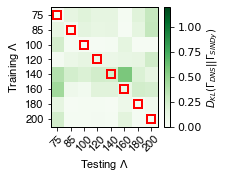


Diagonal values (in-domain performance):
Lambda=75: 0.013939
Lambda=85: 0.032243
Lambda=100: 0.009985
Lambda=120: 0.089068
Lambda=140: 0.234685
Lambda=160: 0.103345
Lambda=180: 0.020835
Lambda=200: 0.030269


In [21]:
### generalisation matrix
import numpy as np
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt

kl_200=np.loadtxt('mode_hist/kl1_divergence200_SLR.txt')
kl_180=np.loadtxt('mode_hist/kl1_divergence180_SLR.txt')
kl_160=np.loadtxt('mode_hist/kl1_divergence160_SLR.txt')
kl_140=np.loadtxt('mode_hist/kl1_divergence140_SLR.txt')
kl_120=np.loadtxt('mode_hist/kl1_divergence120_SLR.txt')
kl_100=np.loadtxt('mode_hist/kl1_divergence100_SLR.txt')
kl_85=np.loadtxt('mode_hist/kl1_divergence85_SLR.txt')
kl_75=np.loadtxt('mode_hist/kl1_divergence75_SLR.txt')
kl_50=np.loadtxt('mode_hist/kl1_divergence50_SLR.txt')
generalisation_matrix_SLR=np.array([kl_50,kl_75,kl_85,kl_100,kl_120,kl_140,kl_160,kl_180,kl_200])
print(len(generalisation_matrix_SLR[0]))

# Extract the relevant part (skip first column)
matrix = generalisation_matrix_SLR[1:,1:]
print(matrix.shape)
# Subtract diagonal element from each row
diagonal_subtracted_matrix = np.zeros_like(matrix)
for i in range(matrix.shape[0]):
    diagonal_value = matrix[i, i]  # Get diagonal element for row i
    diagonal_subtracted_matrix[i, :] = np.abs(matrix[i, :])

plt.figure(figsize=(2.4, 2.2))
plt.imshow(diagonal_subtracted_matrix, cmap='Greens', aspect='auto',vmin=0,vmax=1.2)
cbar = plt.colorbar()
cbar.set_label('$D_{KL}(\Gamma_{DNS}||\Gamma_{SINDy})$ ', fontsize=10, fontproperties=helvetica)
plt.xticks(ticks=np.arange(8), labels=[75,85,100,120,140,160,180,200], fontproperties=helvetica,rotation=45)
plt.yticks(ticks=np.arange(8), labels=[75,85,100,120,140,160,180,200], fontproperties=helvetica)
plt.xlabel('Testing $\Lambda$', fontproperties=helvetica)
plt.ylabel('Training $\Lambda$', fontproperties=helvetica)

# Mark diagonal elements with red squares
for i in range(min(matrix.shape)):
    plt.plot(i, i, 'rs', markersize=8, markerfacecolor='none', 
             markeredgewidth=2, markeredgecolor='red')

plt.savefig('mode_hist/generalisation_matrix_sindy_diagonal_subtracted.png', bbox_inches='tight', dpi=500)
plt.show()

# Print diagonal values for reference
print("\nDiagonal values (in-domain performance):")
for i, lam in enumerate([75,85,100,120,140,160,180,200]):
    print(f"Lambda={lam}: {matrix[i,i]:.6f}")

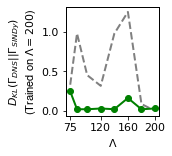

In [22]:
plt.figure(figsize=(2.5,2.3))
ax = plt.gca()
ST_values = [75,85,100,120,140,160,180,200]  # Exclude the first ST value (75)
plt.plot(ST_values,matrix2[-1,:], linestyle='--', color='gray', linewidth=2, label='SINDy')
plt.plot(ST_values,matrix[-1,:], marker='o', linestyle='-', color='green', linewidth=2, label='SLR')
plt.xlabel('$\Lambda$', fontproperties=helvetica)
plt.ylabel('$D_{KL}(\Gamma_{DNS}||\Gamma_{SINDy})$\n(Trained on $\Lambda=200$)', fontproperties=helvetica)
plt.xticks([75,120,160,200])  # Add rotation parameter
plt.tight_layout()  # Add this to prevent labels from being cut off
#plt.legend(prop=helvetica, fontsize=10)
plt.savefig(f'mode_hist/kl_divergence_sindy3_200_diff.png', bbox_inches='tight', dpi=500)

plt.show()

SINDy matrix shape: (9, 9)
SLR matrix shape: (9, 9)
SINDy - Training Λ=50: Mean off-diagonal KL = 6.904240e-01, Diagonal = 2.942230e-01
SINDy - Training Λ=75: Mean off-diagonal KL = 3.006201e-01, Diagonal = 2.949360e-01
SINDy - Training Λ=85: Mean off-diagonal KL = 4.695422e-01, Diagonal = 9.124130e-01
SINDy - Training Λ=100: Mean off-diagonal KL = 4.029566e-01, Diagonal = 1.556350e-01
SINDy - Training Λ=120: Mean off-diagonal KL = 6.598474e-01, Diagonal = 5.381670e-01
SINDy - Training Λ=140: Mean off-diagonal KL = 8.678100e-02, Diagonal = 2.381970e-01
SINDy - Training Λ=160: Mean off-diagonal KL = 2.154869e-01, Diagonal = 2.763450e-01
SINDy - Training Λ=180: Mean off-diagonal KL = 3.814789e-01, Diagonal = 2.187040e-01
SINDy - Training Λ=200: Mean off-diagonal KL = 1.322062e+00, Diagonal = 1.309665e+00
SLR - Training Λ=50: Mean off-diagonal KL = 6.318737e-02, Diagonal = 4.807600e-02
SLR - Training Λ=75: Mean off-diagonal KL = 1.529260e-01, Diagonal = 1.393900e-02
SLR - Training Λ=85: M

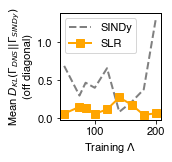


COMPARISON: SINDy vs SLR
Λ      SINDy Off-Diag     SINDy Diag         SLR Off-Diag       SLR Diag          
--------------------------------------------------------------------------------
50     0.690424           0.294223           0.063187           0.048076          
75     0.300620           0.294936           0.152926           0.013939          
85     0.469542           0.912413           0.140240           0.032243          
100    0.402957           0.155635           0.060268           0.009985          
120    0.659847           0.538167           0.119960           0.089068          
140    0.086781           0.238197           0.275712           0.234685          
160    0.215487           0.276345           0.181997           0.103345          
180    0.381479           0.218704           0.046263           0.020835          
200    1.322062           1.309665           0.068772           0.030269          

SINDy - Overall mean (off-diagonal): 0.503244
SLR - Overall me

In [23]:
### Combined plot: SINDy and SLR generalization comparison
import numpy as np
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt

helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

# Load SINDy data
kl_200_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_200.txt')
kl_180_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_180.txt')
kl_160_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_160.txt')
kl_140_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_140.txt')
kl_120_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_120.txt')
kl_100_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_100.txt')
kl_85_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_85.txt')
kl_75_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_75.txt')
kl_50_sindy = np.loadtxt('mode_hist/KLD/kl_divergence_sindy4_50.txt')
generalisation_matrix_sindy = np.array([kl_50_sindy, kl_75_sindy, kl_85_sindy, kl_100_sindy, kl_120_sindy, 
                                        kl_140_sindy, kl_160_sindy, kl_180_sindy, kl_200_sindy])

# Load SLR data
kl_200_slr = np.loadtxt('mode_hist/kl1_divergence200_SLR.txt')
kl_180_slr = np.loadtxt('mode_hist/kl1_divergence180_SLR.txt')
kl_160_slr = np.loadtxt('mode_hist/kl1_divergence160_SLR.txt')
kl_140_slr = np.loadtxt('mode_hist/kl1_divergence140_SLR.txt')
kl_120_slr = np.loadtxt('mode_hist/kl1_divergence120_SLR.txt')
kl_100_slr = np.loadtxt('mode_hist/kl1_divergence100_SLR.txt')
kl_85_slr = np.loadtxt('mode_hist/kl1_divergence85_SLR.txt')
kl_75_slr = np.loadtxt('mode_hist/kl1_divergence75_SLR.txt')
kl_50_slr = np.loadtxt('mode_hist/kl1_divergence50_SLR.txt')
generalisation_matrix_slr = np.array([kl_50_slr, kl_75_slr,kl_85_slr, kl_100_slr, kl_120_slr, 
                                      kl_140_slr, kl_160_slr, kl_180_slr, kl_200_slr])

print(f"SINDy matrix shape: {generalisation_matrix_sindy.shape}")
print(f"SLR matrix shape: {generalisation_matrix_slr.shape}")

lambda_values = [50, 75, 85,100, 120, 140, 160, 180, 200]

# Calculate mean off-diagonal for SINDy
row_means_excl_diag_sindy = []
diagonal_values_sindy = []
for i in range(generalisation_matrix_sindy.shape[0]):
    diagonal_values_sindy.append(generalisation_matrix_sindy[i, i])
    mask = np.ones(generalisation_matrix_sindy.shape[1], dtype=bool)
    mask[i] = False
    row_mean = np.mean(generalisation_matrix_sindy[i, mask])
    row_means_excl_diag_sindy.append(row_mean)
    print(f"SINDy - Training Λ={lambda_values[i]}: Mean off-diagonal KL = {row_mean:.6e}, Diagonal = {diagonal_values_sindy[i]:.6e}")

# Calculate mean off-diagonal for SLR
row_means_excl_diag_slr = []
diagonal_values_slr = []
for i in range(generalisation_matrix_slr.shape[0]):
    diagonal_values_slr.append(generalisation_matrix_slr[i, i])
    mask = np.ones(generalisation_matrix_slr.shape[1], dtype=bool)
    mask[i] = False
    row_mean = np.mean(generalisation_matrix_slr[i, mask])
    row_means_excl_diag_slr.append(row_mean)
    print(f"SLR - Training Λ={lambda_values[i]}: Mean off-diagonal KL = {row_mean:.6e}, Diagonal = {diagonal_values_slr[i]:.6e}")

# Combined plot
plt.figure(figsize=(2.5, 2.3))
ax = plt.gca()

# Plot both off-diagonal means
plt.plot(lambda_values, row_means_excl_diag_sindy, '--', color='grey', linewidth=2, markersize=8, label='SINDy')
plt.plot(lambda_values, row_means_excl_diag_slr, '-s', color='orange', linewidth=2, markersize=8, label='SLR')

# Plot diagonal values
#plt.plot(lambda_values, diagonal_values_sindy, '--o', color='cyan', linewidth=1.5, markersize=6, label='SINDy (self)')
#plt.plot(lambda_values, diagonal_values_slr, '--s', color='orange', linewidth=1.5, markersize=6, label='SLR (in-domain)')

plt.xlabel('Training $\Lambda$', fontproperties=helvetica)
plt.ylabel('Mean $D_{KL}(\Gamma_{DNS}||\Gamma_{SINDy})$\n(off diagonal)', fontproperties=helvetica)
#plt.grid(True, alpha=0.3)
plt.legend(prop=helvetica, fontsize=8)

# Set tick labels to Helvetica
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig('mode_hist/combined_kl_comparison.png', bbox_inches='tight', dpi=500)
plt.show()

# Print comparison statistics
print("\n" + "="*80)
print("COMPARISON: SINDy vs SLR")
print("="*80)
print(f"{'Λ':<6} {'SINDy Off-Diag':<18} {'SINDy Diag':<18} {'SLR Off-Diag':<18} {'SLR Diag':<18}")
print("-"*80)
for i, lam in enumerate(lambda_values):
    print(f"{lam:<6} {row_means_excl_diag_sindy[i]:<18.6f} {diagonal_values_sindy[i]:<18.6f} "
          f"{row_means_excl_diag_slr[i]:<18.6f} {diagonal_values_slr[i]:<18.6f}")

print(f"\nSINDy - Overall mean (off-diagonal): {np.mean(row_means_excl_diag_sindy):.6f}")
print(f"SLR - Overall mean (off-diagonal): {np.mean(row_means_excl_diag_slr):.6f}")

# Save combined results
np.savetxt('mode_hist/combined_comparison.txt',
           np.column_stack([lambda_values, row_means_excl_diag_sindy, diagonal_values_sindy, 
                           row_means_excl_diag_slr, diagonal_values_slr]),
           header='Lambda  SINDy_OffDiag  SINDy_Diag  SLR_OffDiag  SLR_Diag',
           fmt='%d %.6e %.6e %.6e %.6e')

In [ ]:
## plot error
SINDY=np.loadtxt('mode_hist/kl_divergence_sindy.txt', dtype=float)
SLR=np.loadtxt('mode_hist/kl_divergence_SLR.txt', dtype=float)

ST=[75,100,120,160,180,200]
fig, axes = plt.subplots(1, 1, figsize=(3, 3))
plt.plot(ST, SINDY[1:], color='green', marker='o', linewidth=2, markersize=8, label='SINDy')
#plt.plot(ST, SLR[1:], color='orange', marker='o', linewidth=2, markersize=8, label='SLR')
plt.xlabel('Surface Tension ($\Lambda$)', fontproperties=helvetica)
plt.ylabel('KL Divergence', fontproperties=helvetica)

# Set tick labels to Helvetica
ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

#plt.legend(prop=helvetica)
plt.tight_layout()
plt.savefig('mode_hist/error_comparison_SINDY.png', bbox_inches='tight', dpi=500)
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import matplotlib.cm as cm

# Load Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')

# Load data
cost0 = np.loadtxt('test_lang_cost.txt')
cost = np.loadtxt('test_lang_cost80.txt')
cost170 = np.loadtxt('test_lang_cost170.txt')
cost0 = cost0[::-1]
cost = cost[::-1]
cost170 = cost170[::-1]

# Create x-axis arrays

n0 = np.arange( 1, len(cost0)+1,1)
n = np.arange( 1, len(cost)+1,1)
n170 = np.arange( 1, len(cost170)+1,1)

print(f"n0: {n0}, n: {n}, n170: {n170}")

plt.figure(figsize=(2.5, 2.5))

# Get colors from Greens colormap
greens = cm.get_cmap('Greens')
colors = [greens(0.4), greens(0.6), greens(0.85)]

# Plot all three curves with Greens colormap

plt.plot(n[2:], cost[2:], color=colors[0], label='$L=80$')
plt.scatter(n, cost, color=colors[0])
plt.plot(n0[2:], cost0[2:], color=colors[1], label='$L=120$')
plt.scatter(n0, cost0, color=colors[1])



plt.plot(n170[2:], cost170[2:], color=colors[2], label='$L=170$')
plt.scatter(n170, cost170, color=colors[2])

#plt.gca().invert_xaxis()  # Reverse the x-axis
plt.yscale('log')
plt.xlabel('number of terms', fontproperties=helvetica)
plt.ylabel('Cost', fontproperties=helvetica)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)
plt.xticks([14, 12, 10, 8, 6, 4])
plt.legend(prop=helvetica)
plt.savefig("mode_hist/cost.png", bbox_inches='tight', dpi=500)
plt.show()

FileNotFoundError: test_lang_cost.txt not found.

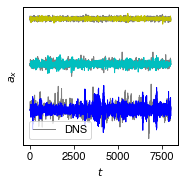

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from matplotlib.font_manager import FontProperties

# Load Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

def read_floats_from_file(filename):
    """Read a text file with one number per line and return a list of floats."""
    float_list = []
    with open(filename, 'r') as file:
        for line in file:
            # Strip whitespace and convert to float, skip empty lines
            if line.strip():
                float_list.append(float(line.strip()))
    return float_list

# Usage example
modes_sim_list = []
modes_real_list = []
n_lists=[702,801,1001,1201,1504,1701]

scale=[14.7025363407212,
 7.10657863315049,
 5.3928464233804,
 3.29485134762626,
 1.4769116522298402,
 1.16509166565443]
## taken from lang reg file (scaling of )

for n in range(0,6):
    num=n_lists[n]
    ### data and sim files was labeled opposit
    data_file = f'lang_reg_data_a/{num}_MC.txt'  
    sim_file = f'lang_reg_data_a/{num}_data.txt'  
    sim_n = scale[n]*np.array(read_floats_from_file(sim_file))+5*n
    data_n = scale[n]*np.array(read_floats_from_file(data_file))+5*n
    sim_n = np.array(sim_n)
    data_n = np.array(data_n)
    modes_real_list.append(np.array(data_n))  
    modes_sim_list.append(np.array(sim_n))

plt.figure(figsize=(2.7,2.7))
t_max=8000
colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k']

plt.plot(modes_real_list[1][:t_max],color='grey',linewidth=1,label='DNS')
plt.plot(modes_sim_list[1][:t_max],color=colors[1],linewidth=1)

plt.plot(modes_real_list[3][:t_max],color='grey',linewidth=1)
plt.plot(modes_sim_list[3][:t_max],color=colors[3],linewidth=1)

plt.plot(modes_real_list[5][:t_max],color='grey',linewidth=1)
plt.plot(modes_sim_list[5][:t_max],color=colors[5],linewidth=1)

plt.yticks([])
plt.xlabel('$t$', fontproperties=helvetica)
plt.ylabel('$a_x$', fontproperties=helvetica)

# Set tick labels to Helvetica
ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

# Legend with Helvetica
legend = plt.legend(prop=helvetica)

plt.tight_layout()
plt.savefig('mode_hist/time_series_comparison.png', bbox_inches='tight', dpi=400)
plt.show()

/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3624262394.py:46: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_real = y_real / trapz(y_real, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3624262394.py:47: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_sim = y_sim / trapz(y_sim, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3624262394.py:50: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  kl_div = trapz(y_real * np.log(y_real / y_sim), x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3624262394.py:46: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_real = y_real / t

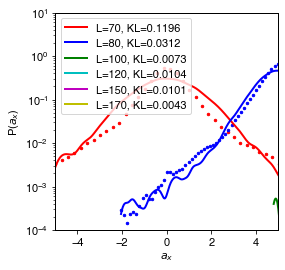


KL DIVERGENCE RESULTS
L =  70: KL divergence = 0.119635
L =  80: KL divergence = 0.031216
L = 100: KL divergence = 0.007328
L = 120: KL divergence = 0.010392
L = 150: KL divergence = 0.010091
L = 170: KL divergence = 0.004284

Mean KL divergence: 0.030491
Std KL divergence:  0.040806


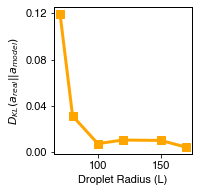

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde, entropy
from matplotlib.font_manager import FontProperties
from scipy.integrate import trapz

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Styling parameters
plt.rcParams['axes.labelweight'] = 'bold'
rc = {'axes.labelsize': 15,
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 10}
plt.rcParams.update(**rc)

legend_properties = {'weight': 'bold'}

# Initialize storage for KL divergences
kl_divergences = []
n_lists = [70, 80, 100, 120, 150, 170]

plt.figure(figsize=(4, 4))
colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k']

for i in range(6):
    kde_real = gaussian_kde(modes_real_list[i])
    kde_sim = gaussian_kde(modes_sim_list[i])
    
    # Create common x-axis for comparison
    x_vals = np.linspace(min(min(modes_real_list[i]), min(modes_sim_list[i])),
                         max(max(modes_real_list[i]), max(modes_sim_list[i])), 1000)

    # Evaluate PDFs
    y_real = kde_real(x_vals)
    y_sim = kde_sim(x_vals)
    
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    y_real = y_real + epsilon
    y_sim = y_sim + epsilon
    
    # Normalize to ensure proper probability distributions
    y_real = y_real / trapz(y_real, x_vals)
    y_sim = y_sim / trapz(y_sim, x_vals)
    
    # Calculate KL divergence: D_KL(P_real || P_sim) = integral(P_real * log(P_real/P_sim))
    kl_div = trapz(y_real * np.log(y_real / y_sim), x_vals)
    kl_divergences.append(kl_div)
    
    color = colors[i % len(colors)]

    plt.plot(x_vals, y_real, color=color, linewidth=2, linestyle='-', 
             label=f'L={n_lists[i]}, KL={kl_div:.4f}')
    plt.scatter(x_vals[::10], y_sim[::10], color=color, s=6)

plt.ylim(0.0001, 10)
plt.xlim(-5, 5)
plt.xlabel(r'$a_x$', fontproperties=helvetica)
plt.ylabel(r'P($a_x$)', fontproperties=helvetica)
plt.yscale('log')
plt.legend(prop=helvetica, fontsize=8)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.savefig("mode_hist/acc_pred_with_kl.png", bbox_inches='tight', dpi=400)
plt.show()

# Print detailed results

print("KL DIVERGENCE RESULTS")

for i, (L, kl) in enumerate(zip(n_lists, kl_divergences)):
    print(f"L = {L:3d}: KL divergence = {kl:.6f}")

print(f"\nMean KL divergence: {np.mean(kl_divergences):.6f}")
print(f"Std KL divergence:  {np.std(kl_divergences):.6f}")

# Save results to file
np.savetxt('mode_hist/kl_divergence_results.txt', 
           np.column_stack([n_lists, kl_divergences]),
           header='L  KL_Divergence',
           fmt='%d %.6f')

# Create summary plot of KL divergences
plt.figure(figsize=(2.9, 2.8))
plt.plot(n_lists, kl_divergences, '-s', color='orange', linewidth=3, markersize=8)
plt.xlabel('Droplet Radius (L)', fontproperties=helvetica)
plt.ylabel('$D_{KL}(a_{real} ||a_{model})$', fontproperties=helvetica)
plt.yticks([0.0,0.04,0.08,0.12])
#plt.title('Model vs Data Divergence', fontproperties=helvetica)
#plt.grid(True, alpha=0.3)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig('mode_hist/kl_divergence_summary.png', bbox_inches='tight', dpi=400)
plt.show()

/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:57: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_real = y_real / trapz(y_real, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:58: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_sim = y_sim / trapz(y_sim, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:61: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  kl_div = trapz(y_real * np.log(y_real / y_sim), x_vals)


L=80:
  Real data - Mean: 5.0000, Std: 1.0168
  Sim data  - Mean: 5.0000, Std: 0.9943
  KL divergence: 0.031216



/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:57: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_real = y_real / trapz(y_real, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:58: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_sim = y_sim / trapz(y_sim, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:61: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  kl_div = trapz(y_real * np.log(y_real / y_sim), x_vals)


L=120:
  Real data - Mean: 15.0000, Std: 0.4551
  Sim data  - Mean: 15.0000, Std: 0.4764
  KL divergence: 0.010392



/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:57: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_real = y_real / trapz(y_real, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:58: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  y_sim = y_sim / trapz(y_sim, x_vals)
/Data_8TB/SINDY droplet new/Code_Upload/ipykernel_486573/3689455871.py:61: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  kl_div = trapz(y_real * np.log(y_real / y_sim), x_vals)


L=170:
  Real data - Mean: 25.0000, Std: 0.2415
  Sim data  - Mean: 25.0000, Std: 0.2310
  KL divergence: 0.004284



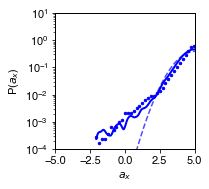


KL DIVERGENCE SUMMARY
L =  80: KL divergence = 0.031216
L = 120: KL divergence = 0.010392
L = 170: KL divergence = 0.004284


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde, norm
from matplotlib.font_manager import FontProperties
from scipy.integrate import trapz

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Styling parameters
plt.rcParams['axes.labelweight'] = 'bold'
rc = {'axes.labelsize': 15,
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 10}
plt.rcParams.update(**rc)

legend_properties = {'weight': 'bold'}

# Initialize storage for KL divergences
kl_divergences = []
n_lists = [70, 80, 100, 120, 150, 170]

plt.figure(figsize=(2.5, 2.5))
colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k']

for i in [1, 3, 5]:
    # Get data
    data_real = modes_real_list[i]
    data_sim = modes_sim_list[i]
    
    # Calculate mean and standard deviation
    mean_real = np.mean(data_real)
    std_real = np.std(data_real)
    mean_sim = np.mean(data_sim)
    std_sim = np.std(data_sim)
    
    # Create KDEs
    kde_real = gaussian_kde(data_real)
    kde_sim = gaussian_kde(data_sim)
    
    # Create common x-axis for comparison
    x_vals = np.linspace(min(min(data_real), min(data_sim)),
                         max(max(data_real), max(data_sim)), 1000)

    # Evaluate PDFs
    y_real = kde_real(x_vals)
    y_sim = kde_sim(x_vals)
    
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    y_real = y_real + epsilon
    y_sim = y_sim + epsilon
    
    # Normalize to ensure proper probability distributions
    y_real = y_real / trapz(y_real, x_vals)
    y_sim = y_sim / trapz(y_sim, x_vals)
    
    # Calculate KL divergence: D_KL(P_real || P_sim) = integral(P_real * log(P_real/P_sim))
    kl_div = trapz(y_real * np.log(y_real / y_sim), x_vals)
    kl_divergences.append(kl_div)
    
    color = colors[i % len(colors)]

    # Plot KDE
    plt.plot(x_vals, y_real, color=color, linewidth=2, linestyle='-', 
             label=f'L={n_lists[i]} ')
    plt.scatter(x_vals[::15], y_sim[::15], color=color, s=6)
    
    # Plot fitted Gaussian
    y_gaussian = norm.pdf(x_vals, mean_real, std_real)
    plt.plot(x_vals, y_gaussian, color=color, linewidth=1.5, linestyle='--', 
             alpha=0.7)
    
    # Print statistics
    print(f"L={n_lists[i]}:")
    print(f"  Real data - Mean: {mean_real:.4f}, Std: {std_real:.4f}")
    print(f"  Sim data  - Mean: {mean_sim:.4f}, Std: {std_sim:.4f}")
    print(f"  KL divergence: {kl_div:.6f}\n")

plt.ylim(0.0001, 10)
plt.xlim(-5, 5)
plt.xlabel(r'$a_x$', fontproperties=helvetica)
plt.ylabel(r'P($a_x$)', fontproperties=helvetica)
plt.yscale('log')
#plt.legend(prop=helvetica, fontsize=2, ncol=1)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.savefig("mode_hist/acc_pred_with_gaussian.png", bbox_inches='tight', dpi=400)
plt.show()

# Print KL divergences summary
print("\n" + "="*60)
print("KL DIVERGENCE SUMMARY")
print("="*60)
for idx, (i, kl) in enumerate(zip([1, 3, 5], kl_divergences)):
    print(f"L = {n_lists[i]:3d}: KL divergence = {kl:.6f}")

(6, 3)
(6, 3)
1: slope=-0.8736, intercept=230.6183, R²=0.5873
r: slope=2.4442, intercept=-464.3361, R²=0.7483
r^3: slope=-1.3086, intercept=238.3295, R²=0.7696


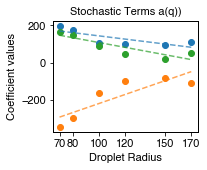

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy.stats import linregress

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Styling parameters
plt.rcParams['axes.labelweight'] = 'bold'
rc = {'axes.labelsize': 15,
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 10}
plt.rcParams.update(**rc)

drift_coef_matrix = []
diff_coef_matrix = []
terms_drift = ['1', 'r', 'r^3']
terms_diff = ['1', 'r', 'r^3']

for file in [702, 803, 1003, 1203, 1503, 1703]:
    drift_coeff = np.loadtxt(f'lang_reg_data_a/{file}_Xf.txt')
    diff_coeff = np.loadtxt(f'lang_reg_data_a/{file}_Xs.txt')
    drift_coef_matrix.append(drift_coeff)
    diff_coef_matrix.append(diff_coeff)

drift_coef_matrix = np.array(drift_coef_matrix)
diff_coef_matrix = np.array(diff_coef_matrix)
print(diff_coef_matrix.shape)
print(drift_coef_matrix.shape)

# X values for fitting (droplet radii)
x_values = np.array([70, 80, 100, 120, 150, 170])

# Define colors for each term
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(3, 2.5))

for i in range(len(terms_diff)):
    # Plot original data
    plt.scatter(x_values, diff_coef_matrix[:, i], label=terms_diff[i], color=colors[i])
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x_values, diff_coef_matrix[:, i])
    
    # Create fitted line
    x_fit = x_values 
    y_fit = slope * x_fit + intercept
    
    # Plot fitted line (dashed)
    plt.plot(x_fit, y_fit, "--", linewidth=1.5, alpha=0.7, color=colors[i])
    
    # Print fit parameters
    print(f"{terms_diff[i]}: slope={slope:.4f}, intercept={intercept:.4f}, R²={r_value**2:.4f}")

plt.xticks(ticks=x_values, labels=['70', '80', '100', '120', '150', '170'])
plt.xlabel("Droplet Radius", fontproperties=helvetica)
plt.ylabel("Coefficient values", fontproperties=helvetica)
plt.title("Stochastic Terms a(q))", fontproperties=helvetica)
#plt.legend(prop=helvetica)

# Set Helvetica font for tick labels
ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig("mode_hist/stochastic_terms_fitted.png", bbox_inches='tight', dpi=400)
plt.show()

(6, 3)
(6, 3)
$K_0$: a=2.5749e-02, b=-7.0350e+00, c=5.6540e+02, R²=0.9576
$K_1$: a=-5.1796e-02, b=1.4838e+01, c=-1.1378e+03, R²=0.9922
$K_2$: a=2.5145e-02, b=-7.3256e+00, c=5.6526e+02, R²=0.9758


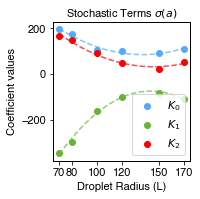

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy.optimize import curve_fit

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Styling parameters
plt.rcParams['axes.labelweight'] = 'bold'
rc = {'axes.labelsize': 15,
      'axes.linewidth': 1.0,
      'font.size': 11,
      'legend.fontsize': 10}
plt.rcParams.update(**rc)

drift_coef_matrix = []
diff_coef_matrix = []
terms_drift = ['$c_0$', '$c_1$', '$c_3$']
terms_diff = ['$K_0$', '$K_1$', '$K_2$']

for file in [702, 803, 1003, 1203, 1503, 1703]:
    drift_coeff = np.loadtxt(f'lang_reg_data_a/{file}_Xf.txt')
    diff_coeff = np.loadtxt(f'lang_reg_data_a/{file}_Xs.txt')
    drift_coef_matrix.append(drift_coeff)
    diff_coef_matrix.append(diff_coeff)

drift_coef_matrix = np.array(drift_coef_matrix)
diff_coef_matrix = np.array(diff_coef_matrix)
print(diff_coef_matrix.shape)
print(drift_coef_matrix.shape)

# X values for fitting (droplet radii)
x_values = np.array([70, 80, 100, 120, 150, 170])

# Define colors for each term
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors=['#52AAFF','#68B536','r']
# Define quadratic function
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

plt.figure(figsize=(2.9, 2.9))

for i in range(len(terms_diff)):
    # Plot original data
    plt.scatter(x_values, diff_coef_matrix[:, i], label=terms_diff[i], color=colors[i])
    
    # Perform quadratic regression
    popt, _ = curve_fit(quadratic, x_values, diff_coef_matrix[:, i])
    
    # Create fitted curve
    x_fit = np.linspace(x_values.min(), x_values.max(), 100)
    y_fit = quadratic(x_fit, *popt)
    
    # Plot fitted curve (dashed)
    plt.plot(x_fit, y_fit, "--", linewidth=1.5, alpha=0.7, color=colors[i])
    
    # Calculate R²
    y_pred = quadratic(x_values, *popt)
    ss_res = np.sum((diff_coef_matrix[:, i] - y_pred)**2)
    ss_tot = np.sum((diff_coef_matrix[:, i] - np.mean(diff_coef_matrix[:, i]))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Print fit parameters
    print(f"{terms_diff[i]}: a={popt[0]:.4e}, b={popt[1]:.4e}, c={popt[2]:.4e}, R²={r_squared:.4f}")

plt.xticks(ticks=x_values, labels=['70', '80', '100', '120', '150', '170'])
plt.xlabel("Droplet Radius (L)", fontproperties=helvetica)
plt.ylabel("Coefficient values", fontproperties=helvetica)
plt.title("Stochastic Terms $\sigma(a)$", fontproperties=helvetica)
plt.legend(prop=helvetica,fontsize=7)

# Set Helvetica font for tick labels
ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig("mode_hist/stochastic_terms_quadratic_fitted.png", bbox_inches='tight', dpi=400)
plt.show()